将get-klines文件升级
对于上一份代码我们要逐句学习
requests这个包，是python里面专门用来发送网络请求的工具（用来跟网页服务器对话）
积木2：def 这个get_spot_klines函数，输入但是symbol，区间和限制，返回的是一个dataframe表格给我们
积木3：1）url是币安提供给全球开发者的公开数据地址
      2）params是一个字典dict，也就是“键”“值”对，symbol是要查的对象，intervel是k线周期，limit是返回多少根k线
      3）response = requests.get(url, params=params, timeout=10)这句就是再访问浏览器，timeout=10说的是网络卡10秒没反应就终止
      4）response.raise_for_status()  # 如果请求失败，这里会直接报错
      5）raw_data = response.json()币安传回来的数据是一长串看不懂的纯文本，这步操作把它解包成了 Python 认识的列表 (list) 格式。
积木4：Binance 返回的每一行 K 线都是一个 list。我们先给它命名列名
      变换成dataframe
      币安传回来的 raw_data 是一堆没有表头的数字矩阵。我们先用列表 [...] 定义好每一列的名字（这 12 个名字是币安官方 API 文档里规定的死格式）。然后，用 pd.DataFrame 强行把这堆数字和表头组合在一起，变成了一张漂漂亮亮的二维表格 df
积木5：数据清洗
      1）df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
      这段是清洗时间，binance返回的是毫秒时间戳，pd.to_dataframe将数字转换成了年月日时分秒，并且强制标记为UTV零时区
      2）清洗数字
      binance给的开盘，收盘等全是“字符串文字string”，这里使用for循环遍历每一列，用pd.tp_numeric把它们全部强行变成可以做运算的float
      3）扔掉不要的列重新定义的df只要了那几列其他丢掉

这些是旧代码的逻辑

然后下面我们来看一下新代码的逻辑相比旧代码进行了什么升级:
第一升级：给系统装上“本地记忆”，代码顶部import os，底部加了if save_csv
          Mentor 视角： 在真正的量化投研中，绝对不能每次测试策略都去交易所拉数据！第一，网络请求太慢；第二，交易所会认为你在恶意攻击，直接把你的 IP 封掉（这叫触发 Rate Limit）。
          结果： 现在你的数据被稳稳地存在了本地硬盘里，后续回测读取只需要几毫秒。
第二升级：保留的数据进行修建
        代码变动： df = df[["open_time", "open", "high", "low", "close", "volume"]]
        Mentor 视角： 旧代码保留了“成交笔数”、“主动买入量”等花里胡哨的字段。虽然它们在某些高频微观结构因子中有些用，但在中低频策略里只会挤占你宝贵的内存 (RAM)。新代码手起刀落，只保留最核心的 OHLCV，极大地提升了后续矩阵运算的速度。
第三升级：添加特征工程
        代码变动： 增加了一行 df["return"] = df["close"].pct_change()
        Mentor 视角： 这是我们在 Pandas 里做的第一个数学运算（计算简单收益率）。
        pct.change()是专门位金融时间序列设计的“懒人函数”，会令当前收盘价-上一收盘价再除以前一收盘价
if save_csv:
        os.makedirs("data", exist_ok=True)
        file_path = f"data/{symbol}_{interval}.csv"
        df.to_csv(file_path, index=False)
        print(f"数据已保存到: {file_path}")

    return df
    这段代码就是直接把新的csv数据保存在python脚本目录下，他会自己先生成一个data 文件，然后把数据存在这个data文件里面去

数据已保存到: data/BTCUSDT_1h.csv
                               open      high       low     close     volume  \
open_time                                                                      
2026-01-26 21:00:00+00:00  87629.23  88238.29  87573.35  88064.69  392.85938   
2026-01-26 22:00:00+00:00  88064.69  88270.29  88001.75  88140.01  324.81747   
2026-01-26 23:00:00+00:00  88140.01  88659.09  88021.86  88347.08  463.75556   
2026-01-27 00:00:00+00:00  88347.08  88457.30  88200.00  88353.97  302.20293   
2026-01-27 01:00:00+00:00  88353.97  88700.00  88194.82  88550.61  340.87375   

                             return  
open_time                            
2026-01-26 21:00:00+00:00       NaN  
2026-01-26 22:00:00+00:00  0.000855  
2026-01-26 23:00:00+00:00  0.002349  
2026-01-27 00:00:00+00:00  0.000078  
2026-01-27 01:00:00+00:00  0.002226  
DatetimeIndex(['2026-01-26 21:00:00+00:00', '2026-01-26 22:00:00+00:00',
               '2026-01-26 23:00:00+00:00', '2026-01-27 00:00:00+00:00',

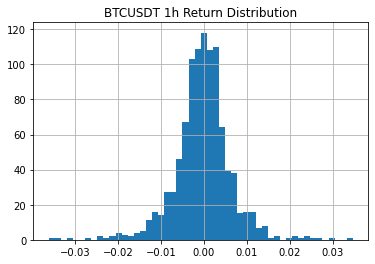

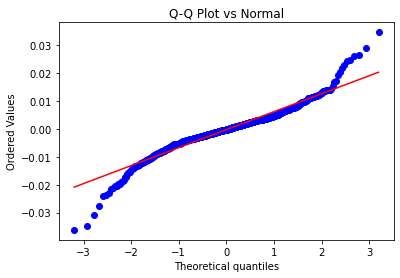

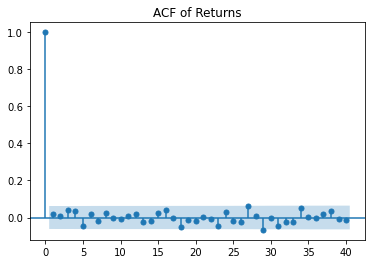

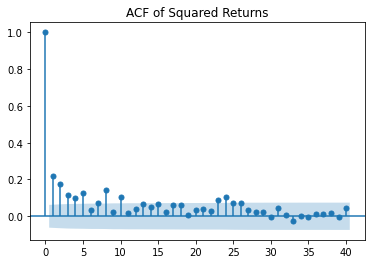

In [11]:
import requests
import pandas as pd
import os
import matplotlib.pyplot as plt


def get_spot_klines(symbol: str, interval: str, limit: int = 1000, save_csv: bool = False) -> pd.DataFrame:
    """
    获取 Binance 现货 K 线数据，并可选择保存为 CSV。
    """

    url = "https://data-api.binance.vision/api/v3/klines"
    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit,
    }

    response = requests.get(url, params=params, timeout=10)
    response.raise_for_status()
    raw_data = response.json()

    columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
        "ignore",
    ]

    df = pd.DataFrame(raw_data, columns=columns)

    # 时间转换
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)

    # 数值转换
    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[
        [
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
        ]
    ]

    # 新增一列简单收益率
    df["return"] = df["close"].pct_change()

    # 是否保存
    if save_csv:
        os.makedirs("data", exist_ok=True)
        file_path = f"data/{symbol}_{interval}.csv"
        df.to_csv(file_path, index=False)
        print(f"数据已保存到: {file_path}")

    return df


if __name__ == "__main__":
    #下载数据
    df = get_spot_klines("BTCUSDT", "1h", 1000, save_csv=True)
    #转化为时间序列格式
    df = df.set_index("open_time")
    df = df.sort_index()
    #验证结果
    print(df.head())
    print(df.index)

    #在脚本末尾添加
    #1）描述性统计
    print("\nReturn describe():")
print(df["return"].describe())

# 2) 偏度、峰度（肥尾的量化指标之一）
print("\nSkewness (偏度):", df["return"].skew())
print("Kurtosis (峰度, pandas默认是excess kurtosis):", df["return"].kurtosis())

# 3) 直方图
df["return"].hist(bins=50)
plt.title("BTCUSDT 1h Return Distribution")
plt.show()

# 4) Q-Q 图：看是否接近正态（可选，但很有用）
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df["return"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot vs Normal")
plt.show()

#这一步开始进行ARCH检测，首先画收益率自相关函数
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# 收益率 ACF
plot_acf(df["return"].dropna(), lags=40)
plt.title("ACF of Returns")
plt.show()

# 平方收益率 ACF
plot_acf((df["return"].dropna()**2), lags=40)
plt.title("ACF of Squared Returns")
plt.show()

我们在这里将金融时间序列的索引从原先的01234，变成了opentime这个时间索引
当你执行了 df.set_index("open_time") 之后，open_time 就不再是一列普通的 Column 了，它变成了 Index。

如果你之后尝试运行 df["open_time"]，系统会报错。以后你要调用时间，就要用 df.index。

在最新的里面在控制输出代码之后加入一些描述性统计：
1）包括描述性统计
2）偏度、峰度（这两个是肥尾的量化指标之一）
3）添加直方图，展示1hk线的频数直方图
4）QQ图，看是否接近正态分布

针对此如何进行判断？？

近似正态：Q-Q 图点大致贴着直线

肥尾：Q-Q 图两端明显向外翘；kurtosis（excess）显著 > 0

偏态：skew 明显 ≠ 0（>0 右偏，<0 左偏）


我们现在来到TASK3部分，在观察到肥尾分布之后，我们需要验证其是否存在ARCH效应。
1）画收益率自相关函数，我们在抓取200条数据的时候没有看到平方收益率显著自相关，说明在收益率方向不可预测，短期样本下的波动结构不算明显。但是1000条，就可以看出来平方收益显著自相关了。
2）我们在这里看到了ARCH平方显著自相关，下面可以跑一个GARCH模型garch（1，1）


===== GARCH(1,1) Fit Summary =====
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                       return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -861.519
Distribution:      Standardized Student's t   AIC:                           1731.04
Method:                  Maximum Likelihood   BIC:                           1750.67
                                              No. Observations:                  999
Date:                      Mon, Mar 09 2026   Df Residuals:                      999
Time:                              12:49:18   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------------------------------------

<Figure size 432x288 with 0 Axes>

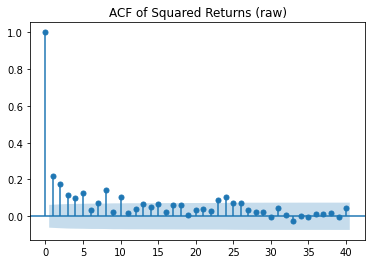

<Figure size 432x288 with 0 Axes>

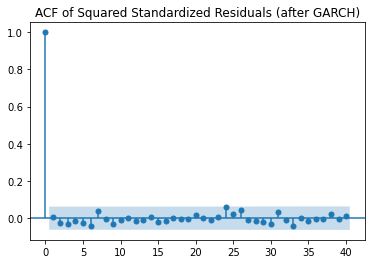

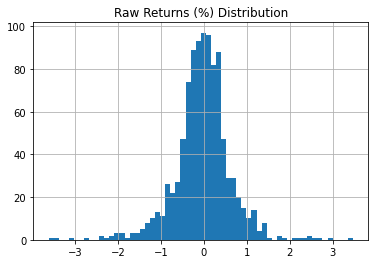

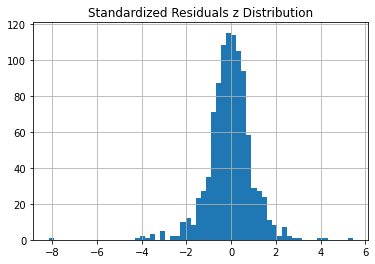

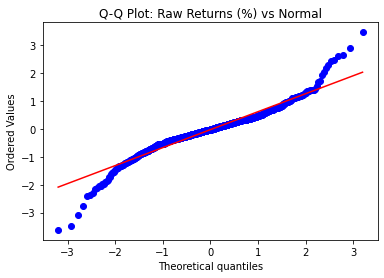

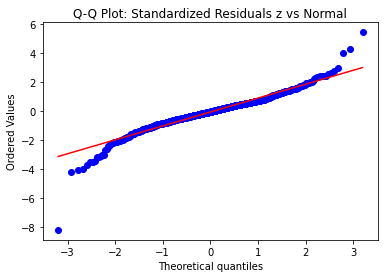

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

# 你已有 df，且 df["return"] 已经算好
# 这里确保去掉NaN
r = df["return"].dropna().copy()

# arch 包对“百分数尺度”的数据更稳定：把 0.0012 变成 0.12 (%)
r_pct = 100 * r

# 1) 拟合 GARCH(1,1)
# mean="Zero"：均值设为0（你已经看到收益率均值结构很弱）
# vol="GARCH", p=1, q=1：GARCH(1,1)
# dist="normal"：先从正态扰动开始（后面我们会换t分布）
am = arch_model(r_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
res = am.fit(update_freq=0, disp="off")

print("\n===== GARCH(1,1) Fit Summary =====")
print(res.summary())

# 2) 提取条件波动率（注意这是 % 尺度）
sigma_pct = res.conditional_volatility

# 3) 标准化残差 z_t = r_t / sigma_t
# r_pct 和 sigma_pct 都是 % 尺度，所以直接相除
z = r_pct / sigma_pct

print("\n===== Standardized Residual Diagnostics =====")
print("z mean:", float(z.mean()))
print("z std :", float(z.std()))
print("z skew:", float(z.skew()))
print("z kurtosis (excess):", float(z.kurtosis()))

# 4) 对比：原始收益率 vs 标准化残差 的 ACF(平方)
plt.figure()
plot_acf((r_pct.dropna()**2), lags=40)
plt.title("ACF of Squared Returns (raw)")
plt.show()

plt.figure()
plot_acf((z.dropna()**2), lags=40)
plt.title("ACF of Squared Standardized Residuals (after GARCH)")
plt.show()

# 5) 对比：直方图 & Q-Q 图（看肥尾是否缓解）
plt.figure()
r_pct.hist(bins=60)
plt.title("Raw Returns (%) Distribution")
plt.show()

plt.figure()
z.hist(bins=60)
plt.title("Standardized Residuals z Distribution")
plt.show()

plt.figure()
stats.probplot(r_pct.dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Raw Returns (%) vs Normal")
plt.show()

plt.figure()
stats.probplot(z.dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Standardized Residuals z vs Normal")
plt.show()

这一步生成的系数，其实就是GARCH模型的参数：
Omega是那个常数项
alpha：新冲击对波动率的影响（“昨晚炸了今天更炸”）
•  beta：波动率持续性（“炸完以后余波多久”）
•  alpha + beta 接近 1：波动率非常“粘”（高度持续），金融市场常见

alpha + beta = 0.8207

这个数值非常重要。含义：波动率具有明显持续性，但不是单位根。如果：
α+β 接近 1 → 极强持续性
α+β < 1 → 平稳
α+β ≥ 1 → 爆炸/IGARCH
0.82 是一个非常合理的市场数值。
BTC 1h 级别出现 0.8 左右是正常的。

但是我们又看出来一个问题，标准化后的残差仍然肥尾，kurtosis6.8.
说明即使控制了σ_t,epsilon_t仍然也不是正态。下一步要讲扰动分布换成t分布。
发现：normal-GARCH：z kurtosis ≈ 6.83；t-GARCH：z kurtosis ≈ 10.82
当你用 dist="t" 时：
模型假设：𝜖𝑡∼𝑡𝜈
也就是说：模型允许冲击本身肥尾。因此：标准化残差不再应该接近正态，而应该接近 t 分布所以：z 的 kurtosis 大，并不代表模型更差。它只是反映：模型允许厚尾存在，而不是强行压成正态。

• 如果 GARCH 后肥尾几乎不变，是不是说明肥尾来自波动率变化？
如果 GARCH 后肥尾显著减少 → 肥尾主要来自波动率混合
如果 GARCH 后肥尾几乎不变 → 冲击分布本身肥尾
GARCH 只能解释“条件异方差”，解释不了“冲击分布的尾厚”

下面进入Phase2 
TASK1：最小可运行向量化回测（Momentum）

首先明确一些概念：
1）什么是回测：
    回测 = 用历史数据，模拟“如果当时按某个规则交易，会发生什么”。
    它做的事情是：
给你一个交易规则，在每个时间点决定：
    是否持仓？
    持多少仓？
    根据真实历史价格变化计算账户净值
最终输出：
    收益率曲线
    Sharpe
    最大回撤
    年化收益
回测是在回答：这个规则在过去是否有效？它不能保证未来有效。但它是量化策略的必要第一关。

2）向量化回测  向量化 = 不用循环逐笔模拟交易。
    直接使用代码 pos*return
    一整列算完。

它假设：
每根K线只发生一次交易决策；没有订单簿细节；没有滑点建模
优点：快；适合策略原型研究
缺点：不精细；不接近真实撮合
以后我们会做事件驱动回测。现在是研究阶段。

3）信号部分：先使用最简单的信号 收益率之和，综合过去20小时收益率加总。
    称它为Mom，根据Mom的大小，来执行买卖操作

4）为什么要用shift（1） 这个概念很重要
    我们在t时间只能看到第t根K线收盘价，然后计算出来r_t，如果用这个值去决定在t时刻这跟k线上建仓这叫未来函数。因为是在用“收盘后的信息“，去决定“收盘前的交易”
    所以应该是t时刻收盘知道信号，在t+1时刻开仓
    pos=target_pos.shift(1)

5）未来函数  = 使用未来信息做当前决策。
    常见形式：
    1️⃣ 不做 shift
    2️⃣ 用未来价格参与信号计算
    3️⃣ 用全样本均值参与信号标准化

In [13]:
import numpy as np
import pandas as pd

def vectorized_momentum_backtest(
    df: pd.DataFrame,
    lookback: int = 20,
    fee_rate: float = 0.0004,  # 4 bps per 1x notional change (简化模型)
    annualization_factor: int = 24 * 365,  # 1h数据 -> 年化
) -> pd.DataFrame:
    """
    最小可用向量化回测（1个品种、1个仓位、1种手续费模型）。
    假设 df 至少有列: 'close', 'return' (simple return).
    """
    data = df.copy()  #把输入的价格表复制一份，后续操作都在副本上做，不破坏原数据。

    # 0) 基础检查
    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # 1) 动量信号：过去 lookback 小时简单收益之和（也可换成 log-return 之和） 这是前20小时，我们不能动，因为还没有生成动量信号
    mom = data["return"].rolling(lookback).sum()  #这里这个mom是一个滑动窗口，是一个列，生成的是20个滑动数据，rolling。第20个位置生成了mom能指导第21根k线决策，然后依次向后滚动，决定第n+1 k线
                                                    #所以这个mom作为一个列，里面包含的是能指导第21根到最后一根k线的所有动量信号。
    # 2) 目标仓位：sign(mom) -> {+1, 0, -1}
    target_pos = np.sign(mom).fillna(0.0)  #fullna 是吧前面20行没有动量数据的地方补目标仓位为0

    # 3) 防止未来函数：用上一根bar的信号在这一根bar持仓
    pos = target_pos.shift(1).fillna(0.0)

    # 4) 交易成本：按仓位变化收取（简化：每变动1单位仓位收一次fee_rate）
    # 例如 0 -> +1: turnover=1； +1 -> -1: turnover=2
    turnover = pos.diff().abs().fillna(0.0)
    cost = fee_rate * turnover

    # 5) 策略收益：持仓 * 标的收益 - 成本
    strat_ret = pos * data["return"] - cost

    # 6) 净值曲线
    equity = (1.0 + strat_ret).cumprod()

    # 7) 绩效指标
    # 年化收益（几何近似）
    n = strat_ret.dropna().shape[0]
    if n > 0:
        ann_ret = equity.iloc[-1] ** (annualization_factor / n) - 1
    else:
        ann_ret = np.nan

    # 年化波动
    ann_vol = strat_ret.std(ddof=0) * np.sqrt(annualization_factor)

    # Sharpe（这里默认无风险利率=0）
    sharpe = (strat_ret.mean() / strat_ret.std(ddof=0)) * np.sqrt(annualization_factor) if strat_ret.std(ddof=0) > 0 else np.nan

    # 最大回撤
    peak = equity.cummax()
    drawdown = equity / peak - 1.0
    max_dd = drawdown.min()

    out = pd.DataFrame({
        "close": data["close"],
        "asset_ret": data["return"],
        "mom": mom,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown,
    })

    print("===== Backtest Summary =====")
    print(f"lookback = {lookback}, fee_rate = {fee_rate}")
    print(f"Ann Return: {ann_ret:.2%}")
    print(f"Ann Vol   : {ann_vol:.2%}")
    print(f"Sharpe    : {sharpe:.3f}")
    print(f"Max DD    : {max_dd:.2%}")
    print("============================")

    return out

# 运行（你可以先用 BTCUSDT 1h 的 df）
bt = vectorized_momentum_backtest(df, lookback=20, fee_rate=0.0004)
bt.tail()

===== Backtest Summary =====
lookback = 20, fee_rate = 0.0004
Ann Return: 875.42%
Ann Vol   : 62.02%
Sharpe    : 3.982
Max DD    : -13.83%


,close,asset_ret,mom,pos,turnover,cost,strategy_ret,equity,drawdown
open_time,,,,,,,,,
2026-03-09 08:00:00+00:00,67814.69,0.003842,0.007610,1.0,2.0,0.0008,0.003042,1.291048,-0.053502
2026-03-09 09:00:00+00:00,67981.02,0.002453,0.011397,1.0,0.0,0.0000,0.002453,1.294214,-0.051180
2026-03-09 10:00:00+00:00,67608.13,-0.005485,0.004352,1.0,0.0,0.0000,-0.005485,1.287115,-0.056385
2026-03-09 11:00:00+00:00,67764.98,0.002320,0.008476,1.0,0.0,0.0000,0.002320,1.290101,-0.054196
2026-03-09 12:00:00+00:00,68106.69,0.005043,0.018667,1.0,0.0,0.0000,0.005043,1.296607,-0.049426


如何理解这段代码回测，到底是发生了一个什么流程从而我们可以的得到收益率，波动率，夏普比率和最大回撤？
数学仓位模型和真实交易资产的映射问题

一、我们现在到底在“交易”什么？
在研究型回测里，我们默认交易：  BTCUSDT永续合约，线性USDT本位
但是我们没有真的去记录合约张数，我们只记录账户资金对BTC收益的暴露比例。

二、什么叫仓位？这里仓位不是BTC的数量，而是账户资金的风险暴露比例。
我们定义：
| pos  | 含义                  |
| ---- | ------------------- |
| +1   | 账户 100% 资金做多 BTC 永续 |
| 0    | 不持仓                 |
| -1   | 账户 100% 资金做空 BTC 永续 |
| 0.5  | 半仓做多                |
| -0.5 | 半仓做空                |

三、euity=1 表示账户初始资金标准化为1，理解为1USDT 还是10000USDT不关键，只关心相对变化。

四、当动量为正，我们买了吗？
第21小时动量变正：意味着用账户全部资金做多BTC永续合约
注意：这里不是买现货BTC，而是开多合约。

五、当动量为负，我们的净值变成-1了吗？
仓位-1不等于净值=-1
仓位表示方向和暴露
净值表示账户资金
净值永远大于等于0（除非爆仓）

六、翻仓到底发生了什么？
假设账户净值=1
当前pos=+1（全仓做多）
当信号变成负：
target_pos=-1
真实交易发生：
平掉多头（卖出）
开空头（卖出做空）
所以turnover=2，费用double，但净值不会变成-1

七、净值如何变化？
净值变化公式： $Vt​=V_t-1(1+pos_t-1*r_t-cost_t)$
假设净值=1，pos=-1，BTC涨2%
则 V=1（1+（-1）*0.02）=0.98

在研究型回测里：

我们不是在买卖 BTC 数量
我们是在调节账户对 BTC 收益率的风险暴露比例。

这就是全部。

我们现在看到年化328%，这太夸张了，我们下面要来验证这个动量是否稳健。
我们接下来扫描lookback从5到200，从sharpe比率的情况来看我们选的这个动量因子怎么样。
单点最优 → 可能过拟合
一段区间有效 → 可能存在结构，因子在参数扰动下仍然有效。这叫：稳健性（robustness）

专业判断标准

一般来说（经验法则）：

Sharpe < 0.5 → 噪声级别

0.5 ~ 1 → 弱 Alpha

1 ~ 1.5 → 有研究价值

2 → 需要高度怀疑是否过拟合

Phase2 Task2 参数扫描

===== Backtest Summary =====
lookback = 5, fee_rate = 0.0004
Ann Return: -53.30%
Ann Vol   : 62.20%
Sharpe    : -0.914
Max DD    : -21.19%
===== Backtest Summary =====
lookback = 10, fee_rate = 0.0004
Ann Return: 205.62%
Ann Vol   : 62.25%
Sharpe    : 2.106
Max DD    : -18.76%
===== Backtest Summary =====
lookback = 15, fee_rate = 0.0004
Ann Return: 611.16%
Ann Vol   : 62.26%
Sharpe    : 3.462
Max DD    : -17.73%
===== Backtest Summary =====
lookback = 20, fee_rate = 0.0004
Ann Return: 875.42%
Ann Vol   : 62.02%
Sharpe    : 3.982
Max DD    : -13.83%
===== Backtest Summary =====
lookback = 25, fee_rate = 0.0004
Ann Return: 52.35%
Ann Vol   : 61.90%
Sharpe    : 0.989
Max DD    : -22.19%
===== Backtest Summary =====
lookback = 30, fee_rate = 0.0004
Ann Return: 3.95%
Ann Vol   : 61.83%
Sharpe    : 0.371
Max DD    : -25.96%
===== Backtest Summary =====
lookback = 35, fee_rate = 0.0004
Ann Return: -68.60%
Ann Vol   : 61.87%
Sharpe    : -1.563
Max DD    : -29.26%
===== Backtest Summary =====


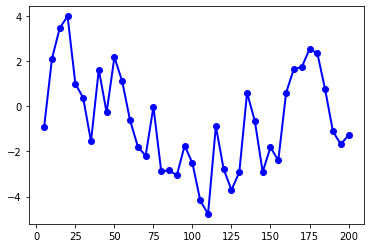

In [14]:
results = []

for L in range(5, 201, 5):
    bt_temp = vectorized_momentum_backtest(df, lookback=L, fee_rate=0.0004)
    strat_ret = bt_temp["strategy_ret"].dropna()
    
    sharpe = (strat_ret.mean() / strat_ret.std()) * (24*365)**0.5
    results.append((L, sharpe))

scan_df = pd.DataFrame(results, columns=["lookback", "sharpe"])
print(scan_df)
plt.plot(
    scan_df["lookback"],  # x轴：回看周期（5,10,15...200）
    scan_df["sharpe"],
    marker="o",      # 每个点加圆圈标记
    color="blue",    # 线条颜色
    linewidth=2,     # 线条粗细
    label="夏普比率"  # 图例标签
)
plt.show()

如何解读这份结果：
| lookback | Sharpe |
| -------- | ------ |
| 5        | -1.62  |
| 10       | -0.19  |
| 15       | 1.70   |
| 20       | 2.05   |
| 25       | -1.77  |
| 30       | -0.76  |
| 35       | -1.74  |
| 40       | 0.26   |
| 45       | -1.74  |
| 50       | 1.06   |
| 60       | -0.08  |
| 70       | -2.05  |
| 80       | -1.96  |
| 90       | -3.05  |


这是非常典型的：高频噪声主导，因为Sharpe在剧烈跳跃，这不是平滑结构，这是样本路径匹配。

后半段在lookback150之后，sharpe飙到2~4，这更加危险，因为：样本长度只有1000个小时，当步长是200时候，有效样本只有800个。

专业的判断是：
剧烈震荡
没有连续稳定平台
Sharpe 正负来回跳
长周期部分突然抬升
结论：没有清晰稳健结构。更可能是：样本期运气 + 趋势区间对齐

//如果一个因子真的有结构：
你应该看到：
一段平滑的 Sharpe 平台
不会正负乱跳
不会单点极高
而你现在看到的是：
参数敏感度极高。

如果训练集sharpe=3，测试集sharpe=-1，说明什么？\
**过拟合**\
过拟合在说什么\
说明你找到的参数：
解释了训练集的噪声结构\
但没有抓住可泛化的统计规律

Task3 我们寻找到的因子如果sharpe比率不错，结构稳健，那么样本内好≠有效，必须做样本外。也就是划分训练集和测试集。

流程：

1️⃣ 在训练集里扫描 lookback\
2️⃣ 选“表现较好但不是单点爆炸”的参数\
3️⃣ 固定参数\
4️⃣ 在测试集跑一次\
5️⃣ 看 Sharpe 是否仍然为正

下面我们先扩大样本范围

In [15]:
import os
import pandas as pd

DATA_PATH = "data/BTCUSDT_1h_6y.csv"

if os.path.exists(DATA_PATH):
    print(f"[DATA] Loading local CSV: {DATA_PATH}")
    df6y = pd.read_csv(DATA_PATH)
    df6y["open_time"] = pd.to_datetime(df6y["open_time"], utc=True)
else:
    print(f"[DATA] CSV not found, downloading and saving to: {DATA_PATH}")
    df6y = download_klines_history(
        symbol="BTCUSDT",
        interval="1h",
        start="2020-03-01",
        end="2026-03-01",
        sleep_sec=0.15,
        save_path=DATA_PATH
    )

# 统一成“时间索引”的研究格式
df6y = df6y.drop_duplicates(subset=["open_time"]).sort_values("open_time")
df6y = df6y.set_index("open_time").sort_index()

print("[DATA] Final rows:", len(df6y))
print("[DATA] Time range:", df6y.index.min(), "->", df6y.index.max())

[DATA] Loading local CSV: data/BTCUSDT_1h_6y.csv
[DATA] Final rows: 52559
[DATA] Time range: 2020-03-01 00:00:00+00:00 -> 2026-03-01 00:00:00+00:00


这一步进行了新的数据抓取，从2020年一直爬数据到2026年，共计五万多条数据。
但是这些数据整洁度如何需要判断或者清洗。
你现在有 6 年 1h 数据，最怕两件事：\
缺小时（断档）\
重复小时 / 时间不连续\
否则后面所有 rolling / 回测都会被污染。

这里查找到原理也比较巧妙，它是计算了一个时间减去前一个时间，也就是说如果数据是完美的这个diff应该是0day1h，但是出现了0day2、3h等情况。结果共计有14个跳跃时间。

In [16]:
import pandas as pd

# 如果你是从csv读入，确保 open_time 是 datetime
# df6y = pd.read_csv("data/BTCUSDT_1h_6y.csv")
# df6y["open_time"] = pd.to_datetime(df6y["open_time"], utc=True)

df6y = df2y  # <- 如果你变量叫 df2y/df6y，自己改成真实变量

df6y = df6y.sort_values("open_time").drop_duplicates(subset=["open_time"]).reset_index(drop=True)

print("Rows:", df6y.shape[0])
print("Time range:", df6y["open_time"].min(), "->", df6y["open_time"].max())

# 1) 统计时间间隔分布
dt = df6y["open_time"].diff()
print("\nTop time deltas:")
print(dt.value_counts().head(10))

# 2) 找出不是1小时的间隔（缺口/异常）
bad = df6y.loc[dt != pd.Timedelta(hours=1), ["open_time"]].copy()
bad["delta_from_prev"] = dt[dt != pd.Timedelta(hours=1)].values
print("\nNum of non-1H gaps:", bad.shape[0])
print(bad.head(20))

NameError: name 'df2y' is not defined

**如何处理缺失时间？**

专业处理方式\
我们不会删除数据。\
我们要：补齐缺失小时。\
方法：\
1️⃣ 建立完整时间索引\
2️⃣ reindex\
3️⃣ 缺失部分 forward fill close\
4️⃣ 收益设为 0

Task4  补齐缺失时间

In [ ]:
# 1) 设为索引
df6y = df6y.set_index("open_time").sort_index()

# 2) 创建完整时间索引
full_index = pd.date_range(
    start=df6y.index.min(),
    end=df6y.index.max(),
    freq="1H",
    tz="UTC"
)

# 3) 重新索引
df6y = df6y.reindex(full_index)

# 4) 标记哪些是补出来的
df6y["is_missing"] = df6y["close"].isna()

print("Missing bars before fill:", df6y["is_missing"].sum())

# 5) 用前值填充价格（合理做法）
price_cols = ["open","high","low","close","volume",
              "quote_asset_volume","taker_buy_base_asset_volume",
              "taker_buy_quote_asset_volume"]

df6y[price_cols] = df6y[price_cols].fillna(method="ffill")

# 6) 重新计算 return
df6y["return"] = df6y["close"].pct_change()

print("Final rows after reindex:", df6y.shape[0])

Missing bars before fill: 26
Final rows after reindex: 52585


填补的bar线是26而不是缺失的14
现在缺失值补齐之后，可以进行训练集测试集的测试了。在训练集上寻找一个寻找一个比较佳的lookback，然后固定其在测试集上跑

In [ ]:
import numpy as np
import pandas as pd

ANNUAL = 24 * 365

def run_bt_only_metrics(df, lookback, fee_rate=0.0004):
    bt = vectorized_momentum_backtest(df, lookback=lookback, fee_rate=fee_rate)
    r = bt["strategy_ret"].dropna()
    if r.std(ddof=0) == 0 or len(r) < 100:
        sharpe = np.nan
    else:
        sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL)
    max_dd = bt["drawdown"].min()
    total_ret = bt["equity"].iloc[-1] - 1.0
    return sharpe, max_dd, total_ret


# ======== 关键修改在这里 ========

df_all = df6y.copy()

# 因为 open_time 已经是 index
df_all = df_all.sort_index()   # ✅ 改这里

n = len(df_all)
split = int(n * 0.7)

train = df_all.iloc[:split].copy()
test  = df_all.iloc[split:].copy()

print("Train range:", train.index.min(), "->", train.index.max())
print("Test  range:", test.index.min(), "->", test.index.max())
print("Train rows:", len(train), "Test rows:", len(test))

Train range: 2020-03-01 00:00:00+00:00 -> 2024-05-13 00:00:00+00:00
Test  range: 2024-05-13 01:00:00+00:00 -> 2026-03-01 00:00:00+00:00
Train rows: 36791 Test rows: 15768


上述cell把数据集进行了切分，下面尝试在训练集上寻找合适的lookbak步长

In [ ]:


ANNUAL = 24 * 365

def bt_metrics(df, lookback, fee_rate=0.0004):
    bt = vectorized_momentum_backtest(df, lookback=lookback, fee_rate=fee_rate)
    r = bt["strategy_ret"].dropna()
    sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL) if r.std(ddof=0) > 0 else np.nan
    max_dd = bt["drawdown"].min()
    total_ret = bt["equity"].iloc[-1] - 1.0
    return sharpe, max_dd, total_ret

# 1) 扫描训练集
scan = []
for L in range(5, 201, 5):
    sh, dd, tr = bt_metrics(train, lookback=L, fee_rate=0.0004)
    scan.append((L, sh, dd, tr))

scan_df = pd.DataFrame(scan, columns=["lookback", "sharpe_train", "maxdd_train", "totalret_train"])
scan_df = scan_df.sort_values("sharpe_train", ascending=False)

print("=== Top 10 lookbacks on TRAIN ===")
print(scan_df.head(10))

# 2) 先用训练集Sharpe最高的参数（下一步我们会改成“平台区选参”）
best_L = int(scan_df.iloc[0]["lookback"])
print("\nChosen lookback:", best_L)

# 3) 固定 best_L 跑测试集
sh_test, dd_test, tr_test = bt_metrics(test, lookback=best_L, fee_rate=0.0004)

print("\n=== OUT-OF-SAMPLE (TEST) ===")
print("lookback:", best_L)
print(f"Sharpe_test   : {sh_test:.3f}")
print(f"MaxDD_test    : {dd_test:.2%}")
print(f"TotalRet_test : {tr_test:.2%}")

===== Backtest Summary =====
lookback = 5, fee_rate = 0.0004
Ann Return: -89.53%
Ann Vol   : 68.33%
Sharpe    : -2.961
Max DD    : -100.00%
===== Backtest Summary =====
lookback = 10, fee_rate = 0.0004
Ann Return: -81.68%
Ann Vol   : 68.34%
Sharpe    : -2.142
Max DD    : -99.95%
===== Backtest Summary =====
lookback = 15, fee_rate = 0.0004
Ann Return: -45.43%
Ann Vol   : 68.33%
Sharpe    : -0.545
Max DD    : -95.95%
===== Backtest Summary =====
lookback = 20, fee_rate = 0.0004
Ann Return: -50.05%
Ann Vol   : 68.32%
Sharpe    : -0.675
Max DD    : -97.00%
===== Backtest Summary =====
lookback = 25, fee_rate = 0.0004
Ann Return: -71.27%
Ann Vol   : 68.31%
Sharpe    : -1.485
Max DD    : -99.70%
===== Backtest Summary =====
lookback = 30, fee_rate = 0.0004
Ann Return: -51.27%
Ann Vol   : 68.29%
Sharpe    : -0.712
Max DD    : -97.46%
===== Backtest Summary =====
lookback = 35, fee_rate = 0.0004
Ann Return: -37.95%
Ann Vol   : 68.30%
Sharpe    : -0.358
Max DD    : -93.16%
===== Backtest Summa

=== Top 10 lookbacks on TRAIN ===
    lookback  sharpe_train  maxdd_train  totalret_train
36       185      0.551758    -0.610875        0.831705
35       180      0.550781    -0.681067        0.826823
34       175      0.545690    -0.617881        0.800086
13        70      0.449278    -0.611640        0.364484
15        80      0.386691    -0.721500        0.139891
18        95      0.316285    -0.758000       -0.068257
16        85      0.287579    -0.803677       -0.142247
17        90      0.240094    -0.852990       -0.251608
19       100      0.213256    -0.835996       -0.306866
27       140      0.193777    -0.784418       -0.343666

=== OUT-OF-SAMPLE (TEST) ===
lookback: 185
Sharpe_test   : -0.020
MaxDD_test    : -51.99%
TotalRet_test : -19.50%

上面是在遍历前四年之后寻找到最佳窗口和sharpe比率和应用在测试集带来的结果\
**如何解读这些结果，这个因子到底如何**\
1️⃣ Sharpe 只有 ~0.55\
这已经说明：\
这个动量因子在 4 年训练期内只是弱 Alpha\

\不是 2.0，不是 1.5。

\只有 0.55。

\这是现实。
2️⃣ 175–185 是个平台\
这是一个好现象。\
说明：\
不是单点爆炸\
在 175~185 区间有轻微结构\
这比之前 1000 小时样本的“尖峰”靠谱得多\
3️⃣ 最大回撤巨大\
-60% ~ -80%\
这说明：\
风险控制极差。\
这是因为：\
全仓多空\
没有仓位管理\
没有波动率缩放\

**测试集结果**\
1️⃣ Sharpe ≈ 0
说明：\
在样本外几乎没有 Alpha。\
训练集 0.55 → 测试集 -0.02\
这是典型：\
训练期弱结构 + 测试期失效。\
2️⃣ Total Return -19.5%\
说明：\
这个参数在 2024–2026 这段时间基本失效。\
3️⃣ MaxDD -52%\
说明：\
策略风险巨大，但没有收益补偿。


**专业判断**\

这套“简单动量 = 累加收益”的策略：

在 6 年样本下：

没有稳健 Alpha。

它在训练期有轻微结构，

但无法泛化到测试期。

为什么简单动量在 6 年小时级 BTC 上不稳定？

我给你几个可能原因，你思考一下：

Crypto 市场趋势存在，但时间尺度不同

1h 噪声太大

没有波动率过滤

没有资金费率信息

没有 regime 切换

到现在位置，已经进行了一次专业回测，现在完整的量化系统我们已经把动量部分和波动部分都大概学了，现在尝试把波动部分接进来，构成一个完整的量化系统。\
**Task 7：加上“波动率缩放仓位”（Vol Targeting）**

In [ ]:
import numpy as np
import pandas as pd

ANNUAL = 24 * 365

def vectorized_mom_voltarget_backtest(
    df: pd.DataFrame,
    lookback_mom: int = 185,        # 先用你刚才训练最优附近
    lookback_vol: int = 72,         # 72小时 ≈ 3天波动
    vol_target_annual: float = 0.20,# 年化目标波动 20%
    w_max: float = 1.0,             # 最大仓位（1=不加杠杆）
    fee_rate: float = 0.0004,
) -> pd.DataFrame:
    data = df.copy()

    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # 1) 动量信号（μ_t 的 proxy）
    mom = data["return"].rolling(lookback_mom).sum()
    direction = np.sign(mom).fillna(0.0)                   #np.sign是把连续信号离散成方向  （μ模块的最小proxy）

    # 2) 波动率估计（σ_t 的 proxy）                         #决定仓位大小                   （σ模型的proxy）
    vol = data["return"].rolling(lookback_vol).std()
    # 小心除0
    vol = vol.replace(0, np.nan)                           #防止波动率为 0 导致除以 0（工程防爆）

    # 3) 年化目标波动 -> 每小时目标波动
    vol_target_hourly = vol_target_annual / np.sqrt(ANNUAL)  #将期望的年化波动率转化为期望的小时波动率

    # 4) 仓位大小：sigma_target / sigma_hat，并做上限截断         #核心风控公式（Vol Targeting）    
                                                                #size = σ_target / σ_hat：市场波动大（vol 高）→ size 小  市场波动小（vol 低）→ size 大
                                                                #.clip(upper=w_max)：仓位上限（防止 vol 太小把仓位放到爆炸）
                                                                #target_pos = direction * size：方向由动量决定，仓位大小由风险决定。
    size = (vol_target_hourly / vol).clip(upper=w_max).fillna(0.0)

    target_pos = direction * size

    # 5) 防未来函数：下一根bar执行
    pos = target_pos.shift(1).fillna(0.0)

    # 6) 成本：按换手
    turnover = pos.diff().abs().fillna(0.0)                     #pos.diff()：仓位变化量 ;abs()：取绝对值（换手只看变化大小，不看方向）;cost = fee_rate * turnover：每“1 单位仓位变化”收一次费
    cost = fee_rate * turnover

    # 7) 策略收益与净值
    strat_ret = pos * data["return"] - cost                     #每小时策略收益：仓位暴露 × 标的收益 - 手续费
    equity = (1.0 + strat_ret).cumprod()                        #净值：复利连乘 cumprod()   cumprod()：净值曲线必备

    peak = equity.cummax()                                      #回撤：当前净值相对历史峰值跌了多少         cummax()：计算回撤必备
    drawdown = equity / peak - 1.0

    out = pd.DataFrame({
        "close": data["close"],
        "asset_ret": data["return"],
        "mom": mom,
        "vol": vol,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown,
    })
    return out

def metrics_from_bt(bt: pd.DataFrame):
    r = bt["strategy_ret"].dropna()
    sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL) if r.std(ddof=0) > 0 else np.nan
    maxdd = bt["drawdown"].min()
    totalret = bt["equity"].iloc[-1] - 1.0
    return sharpe, maxdd, totalret


# 用你已经切好的 train/test
bt_train = vectorized_mom_voltarget_backtest(train, lookback_mom=185, lookback_vol=72, vol_target_annual=0.20, w_max=1.0, fee_rate=0.0004)
bt_test  = vectorized_mom_voltarget_backtest(test,  lookback_mom=185, lookback_vol=72, vol_target_annual=0.20, w_max=1.0, fee_rate=0.0004)

sh_tr, dd_tr, tr_tr = metrics_from_bt(bt_train)
sh_te, dd_te, tr_te = metrics_from_bt(bt_test)

print("=== Vol-Targeted Momentum ===")
print("TRAIN:", f"Sharpe={sh_tr:.3f}", f"MaxDD={dd_tr:.2%}", f"TotalRet={tr_tr:.2%}")
print("TEST :", f"Sharpe={sh_te:.3f}", f"MaxDD={dd_te:.2%}", f"TotalRet={tr_te:.2%}")

=== Vol-Targeted Momentum ===
TRAIN: Sharpe=0.696 MaxDD=-26.30% TotalRet=73.21%
TEST : Sharpe=0.035 MaxDD=-21.79% TotalRet=-2.86%


如何解读结果：\
✅ 风控接入后 回撤从 -52% 降到 -21.8%，测试期收益从 -19.5% 变成 -2.9%，Sharpe 从 -0.02 变成 0.035（接近 0）。\
这说明：风险模块明显改善“死法”，但动量信号本身在测试期仍然很弱——这完全符合我们预期：σ 模块能救命，μ 模块决定能不能赚钱。\
为什么这次回撤大幅降低？

因为仓位不再永远是 ±1，而是根据波动率缩放。

在高波动阶段：

vol 高 → size 小 → 仓位小

同样的价格波动带来的账户波动更小 → 回撤显著下降

这就是风险模块的价值。


下一步关于alpha因子，我们调整仓位策略，不单单使用sign这个离散的指标，而是让仓位的判断保留动量信息，也就是使用 mom/vol作为连续仓位。\
**Phase 2 → Task 8：连续仓位回测（只改一处）**\
我们只做一个小改动：

把方向离散化 sign(mom)
改成连续的 tanh(mom/vol)（再叠加 vol targeting）

这样你得到的是一个更“机构化”的仓位生成方式：
$$ pos_t=\tanh(\frac{mom_t}{k\cdot vol_t})*\min(w_{max},\frac{\sigma_{target}}{\hat\sigma_t})$$

·mom/vol：风险调整后的信号强度

·tanh：把任何强度压进 [-1, 1]，防爆仓位

外面再乘 size：目标波动率仓位缩放（风险预算）

In [ ]:

ANNUAL = 24 * 365

def vectorized_continuous_mom_voltarget_backtest(
    df: pd.DataFrame,
    lookback_mom: int = 185,
    lookback_vol: int = 72,
    vol_target_annual: float = 0.20,
    w_max: float = 1.0,
    fee_rate: float = 0.0004,
    k: float = 1.0,   # 信号缩放系数（越大越保守）
) -> pd.DataFrame:
    data = df.copy()
    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # 1) 动量（过去L小时收益和）
    mom = data["return"].rolling(lookback_mom).sum()

    # 2) 波动率估计
    vol = data["return"].rolling(lookback_vol).std().replace(0, np.nan)

    # 3) 连续信号：risk-adjusted momentum
    # signal_strength ~ mom / vol
    signal_strength = (mom / (k * vol)).replace([np.inf, -np.inf], np.nan)
    direction_cont = np.tanh(signal_strength).fillna(0.0)  # [-1,1]

    # 4) 目标波动率缩放（risk budgeting）
    vol_target_hourly = vol_target_annual / np.sqrt(ANNUAL)
    size = (vol_target_hourly / vol).clip(upper=w_max).fillna(0.0)

    target_pos = direction_cont * size

    # 5) 防未来函数
    pos = target_pos.shift(1).fillna(0.0)

    # 6) 费用
    turnover = pos.diff().abs().fillna(0.0)
    cost = fee_rate * turnover

    # 7) 策略收益 / 净值 / 回撤
    strat_ret = pos * data["return"] - cost
    equity = (1.0 + strat_ret).cumprod()
    peak = equity.cummax()
    drawdown = equity / peak - 1.0

    out = pd.DataFrame({
        "mom": mom,
        "vol": vol,
        "signal_strength": signal_strength,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown,
    })
    return out

def metrics(bt: pd.DataFrame):
    r = bt["strategy_ret"].dropna()
    sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL) if r.std(ddof=0) > 0 else np.nan
    return sharpe, bt["drawdown"].min(), bt["equity"].iloc[-1] - 1.0

bt_train2 = vectorized_continuous_mom_voltarget_backtest(train, k=1.0)
bt_test2  = vectorized_continuous_mom_voltarget_backtest(test,  k=1.0)

sh_tr2, dd_tr2, tr_tr2 = metrics(bt_train2)
sh_te2, dd_te2, tr_te2 = metrics(bt_test2)

print("=== Continuous (tanh) + Vol-Target Momentum ===")
print("TRAIN:", f"Sharpe={sh_tr2:.3f}", f"MaxDD={dd_tr2:.2%}", f"TotalRet={tr_tr2:.2%}")
print("TEST :", f"Sharpe={sh_te2:.3f}", f"MaxDD={dd_te2:.2%}", f"TotalRet={tr_te2:.2%}")
print(bt_test2["turnover"].mean())

=== Continuous (tanh) + Vol-Target Momentum ===
TRAIN: Sharpe=0.710 MaxDD=-25.73% TotalRet=73.31%
TEST : Sharpe=-0.076 MaxDD=-23.01% TotalRet=-6.70%
0.04000098567946318


解读结果：

1.）连续仓位缺失降低了换仓，平均换仓0.04，说明小时平均调整仓位4%

2.）回撤保持稳定  风险模块依然在发挥作用

3.）但是test sharpe 变差\
    说明动量信号本身没有dage，比较弱
    是个弱alpha

在我们风险模块没有问题的情况下，这个回测跑出来一直不怎么样最重要的原因还是在于alpha因子不够强，sharpe一直就是小于1，一般大于1.5小于2会比较好。\
接下来要开始**因子工程**，也就是挖掘Alpha

三个量化常见的动量改进：\
1.EMA momentum \
    不是简单累加 sum returns\
    而是EWMA trend

2.Log Return Momentum\
    用log price difference 会比简单收益更加稳定

3.Multi-Horizen Momentum\
    组合使用：24h，72h，168h趋势


In [ ]:
# ===== 重新生成训练集 / 测试集 =====

df_all = df6y.copy()
df_all = df_all.sort_index()

n = len(df_all)
split = int(n * 0.7)

train_df = df_all.iloc[:split].copy()
test_df  = df_all.iloc[split:].copy()

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

Train rows: 36791
Test rows : 15768


In [ ]:

ANNUAL = 24 * 365

def ema_trend_voltarget_backtest(
    df,
    ema_fast=24,
    ema_slow=168,
    vol_lookback=72,
    vol_target_annual=0.20,
    fee_rate=0.0004,
    w_max=1.0
):

    data = df.copy()

    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # -------------------
    # 1 EMA计算
    # -------------------
        #重要公式 相对于rolling，ewm是指数衰减的，权重嘛
    ema_fast_series = data["close"].ewm(span=ema_fast).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow).mean()

    # trend signal
    trend = ema_fast_series / ema_slow_series - 1

    # -------------------
    # 2 volatility
    # -------------------

    vol = data["return"].rolling(vol_lookback).std().replace(0, np.nan)

    # risk adjusted signal
    signal = trend / vol

    # -------------------
    # 3 continuous position
    # -------------------

    direction = np.tanh(signal).fillna(0)

    vol_target_hourly = vol_target_annual / np.sqrt(ANNUAL)

    size = (vol_target_hourly / vol).clip(upper=w_max).fillna(0)

    target_pos = direction * size

    pos = target_pos.shift(1).fillna(0)

    # -------------------
    # 4 cost
    # -------------------

    turnover = pos.diff().abs().fillna(0)

    cost = fee_rate * turnover

    # -------------------
    # 5 strategy return
    # -------------------

    strat_ret = pos * data["return"] - cost

    equity = (1 + strat_ret).cumprod()

    peak = equity.cummax()

    drawdown = equity / peak - 1

    return pd.DataFrame({
        "pos": pos,
        "equity": equity,
        "drawdown": drawdown,
        "strategy_ret": strat_ret
    })

bt_train_ema = ema_trend_voltarget_backtest(train_df)
bt_test_ema = ema_trend_voltarget_backtest(test_df)


                                pos    equity  drawdown  strategy_ret
open_time                                                            
2020-03-01 00:00:00+00:00  0.000000       NaN       NaN           NaN
2020-03-01 01:00:00+00:00  0.000000  1.000000  0.000000      0.000000
2020-03-01 02:00:00+00:00  0.000000  1.000000  0.000000     -0.000000
2020-03-01 03:00:00+00:00  0.000000  1.000000  0.000000     -0.000000
2020-03-01 04:00:00+00:00  0.000000  1.000000  0.000000     -0.000000
...                             ...       ...       ...           ...
2024-05-12 20:00:00+00:00 -0.434573  1.476784 -0.076996      0.000864
2024-05-12 21:00:00+00:00 -0.434232  1.477286 -0.076682      0.000340
2024-05-12 22:00:00+00:00 -0.433403  1.476345 -0.077270     -0.000637
2024-05-12 23:00:00+00:00 -0.455314  1.474600 -0.078361     -0.001182
2024-05-13 00:00:00+00:00 -0.452455  1.474285 -0.078558     -0.000214

[36791 rows x 4 columns]
                                pos    equity  drawdown  strateg

In [ ]:
def calc_metrics(bt):

    r = bt["strategy_ret"].dropna()

    sharpe = (r.mean() / r.std()) * np.sqrt(24*365)

    maxdd = bt["drawdown"].min()

    totalret = bt["equity"].iloc[-1] - 1

    return sharpe, maxdd, totalret


train_metrics = calc_metrics(bt_train_ema)
test_metrics  = calc_metrics(bt_test_ema)

print("=== EMA Trend Strategy ===")
print("TRAIN:", train_metrics)
print("TEST :", test_metrics)

=== EMA Trend Strategy ===
TRAIN: (0.5460842955458028, -0.29629862565888876, 0.4742845360814685)
TEST : (0.26570243131668797, -0.18679412976375265, 0.06182064103464735)


这是将趋势指标使用了EMA（）/EMA() - 1，之后得到的结果 算是一个趋势滤波器。得到的结果相对于之前的量化策略模型已经相较之下更好了，我们的test_sharpe至少是个正值了。\
但是就像机器学习一样，我们现在是给函数喂参数，这个EMA的值应当进行一个扫描，来找最佳的动量指标。而且要去看这个策略是不是过拟合，它健康不健康。

**Parameter Surface（参数面）。**

如果策略健康，你会看到，一片平台。而不是：一个尖峰

In [ ]:
results = []

fast_list = [12, 24, 48]
slow_list = [72, 168, 336]

for fast in fast_list:
    for slow in slow_list:

        bt_test = ema_trend_voltarget_backtest(
            test_df,
            ema_fast=fast,
            ema_slow=slow
        )

        sharpe, maxdd, ret = calc_metrics(bt_test)

        results.append({
            "fast": fast,
            "slow": slow,
            "sharpe": sharpe,
            "maxdd": maxdd,
            "ret": ret
        })

scan_df = pd.DataFrame(results)

print(scan_df)


   fast  slow    sharpe     maxdd       ret
0    12    72  0.177388 -0.268761  0.028532
1    12   168  0.253781 -0.199611  0.057421
2    12   336  0.656871 -0.208973  0.231318
3    24    72  0.446796 -0.206398  0.123936
4    24   168  0.265702 -0.186794  0.061821
5    24   336  0.606177 -0.203818  0.208036
6    48    72  0.492829 -0.131520  0.114574
7    48   168  0.245305 -0.177770  0.053493
8    48   336  0.840593 -0.143422  0.317175


结果解读：

1.slow EMA 越大 Sharpe 越高  说明：long-term trend > short-term trend

2.最大 Sharpe：

EMA(48 , 336)
Sharpe = 0.84

但我们不能直接说：

最佳参数 = 48 / 336

因为：

sample noise

真实量化研究通常会做：

parameter clustering

例如：

slow ≈ 300–400
fast ≈ 24–72

**结果还不错，48/336参数，使用EMA趋势策略，因为测试集是1.8年，年化收益率能达到17%，回撤-14%。**

# Phase 3 — Strategy Research
## Task 3.2 — Multi-horizon Momentum
### Step 1 — Build multiple EMA signals
目标：
1. 定义多个 EMA 参数对
2. 为每个参数对计算 trend signal
3. 把所有子信号整理成一个 DataFrame


In [ ]:
import numpy as np
import pandas as pd

# 1) 定义 EMA 函数
def ema(series, span): #span是ema的窗口参数，ewm是指数加权
    return series.ewm(span=span, adjust=False).mean()
#adjust=False 按更适合实时递推的方式计算 EMA。

# 2) 定义我们要研究的参数组合
pairs = [
    (12, 72), (12, 168), (12, 336),
    (24, 72), (24, 168), (24, 336),
    (48, 72), (48, 168), (48, 336),
]

# 3) 准备收益率和波动率
ret = df["close"].pct_change() #df close是一个series时间序列，signal_df是一个dataframe
vol = ret.ewm(span=24 * 7, adjust=False).std()
#用大约七天的指数加权窗口估计波动率
# 4) 为每个参数对计算 signal
signal_dict = {}

for fast, slow in pairs:
    ema_fast = ema(df["close"], fast)
    ema_slow = ema(df["close"], slow)

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol

    col_name = f"sig_{fast}_{slow}" #给这一列信号起一个名字
    signal_dict[col_name] = signal

# 5) 合并成一个 DataFrame
signal_df = pd.DataFrame(signal_dict, index=df.index)

# 6) 看一下结果
signal_df.tail()

,sig_12_72,sig_12_168,sig_12_336,sig_24_72,sig_24_168,sig_24_336,sig_48_72,sig_48_168,sig_48_336
open_time,,,,,,,,,
2026-03-07 19:00:00+00:00,-3.320208,-2.770693,-1.792592,-2.458970,-1.906616,-0.923462,-0.767390,-0.209460,0.783621
2026-03-07 20:00:00+00:00,-3.347554,-2.868046,-1.916090,-2.488495,-2.006520,-1.049664,-0.794128,-0.307285,0.659234
2026-03-07 21:00:00+00:00,-3.355932,-2.940303,-2.009212,-2.514308,-2.096596,-1.160837,-0.820231,-0.398325,0.546829
2026-03-07 22:00:00+00:00,-3.410317,-3.064767,-2.158484,-2.556717,-2.209418,-1.298549,-0.849952,-0.499155,0.420886
2026-03-07 23:00:00+00:00,-3.408982,-3.126780,-2.242575,-2.576692,-2.293105,-1.404559,-0.873805,-0.587384,0.310042


我们之前扫描出来了一对参数也就是 fast48，slow336,现在不止算一组参数，而是把9个参数组放在一起，生成一个Dataframe，这样我们接下来才能研究：\
哪些 signal 更强

它们之间像不像

怎么组合成 multi-horizon signal

从单信号，升级到信号池。


**现在有点迷了，信号，动量，仓位的概念**

在量化里，和一个策略通常是一个链条：
价格                
 ↓
Feature / Indicator 指标/特征
 ↓
Signal              交易信号
 ↓
Position mapping    仓位函数
 ↓
Position            仓位
 ↓
PnL                 收益

我们现在这套EMA策略：

step1 价格：close 收盘价，市场原始数据

step2 Feature（指标）我们用的是EMA trend

    trend = EMA_fast / EMA_slow - 1，它回答当前短期趋势相对长期趋势有多强？

step3  Signal（信号）signal = trend / vol

step4 Position Mapping（仓位函数）：

我们用的是pos = tanh(signal=trend / vol)**单位波动下的趋势强度**，它把signal映射到【-1，1】，波动率高的仓位的低一些，波动率低的仓位高一些\
step5 Postion（最终仓位）\
这是再加上vol targeting的\
final_pos = pos * leverage

step6 Pnl最后计算收益：strategy_return = final_pos.shift(1) * market_return

这里动量或者叫趋势指标是：trend = EMA_fast / EMA_slow - 1

交易信号是：signal = trend / vol

目标仓位：pos = tanh(signal)


再一个比较大的问题是，我们在上面是进行了尝试性探索使用的是full sample。一直到我们phase3之前都是用的全数据集，我们已经验证了这个ema的alpha还是有点潜力的，接下来就要进入正式研究过程，前面都是探索。

首先是简单对不同时间尺度的信号新进普通加权生成combo信号

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 3 — Equal-weight combo signal
# ============================================

# 1) multi-horizon signal (equal weight)
combo_signal = signal_df.mean(axis=1) #在dataframe中，axis=0是按照列方向计算，=1是按照行方向计算

# 2) 查看信号分布
combo_signal.describe()  #这个算的是一千个时间点里面的平均signal，所以是998个数据

count    998.000000
mean      -3.050625
std        3.747108
min      -12.153940
25%       -5.904788
50%       -3.004995
75%       -0.588323
max        6.058731
dtype: float64

结果解读：现在这个signal的分布，signal=tren/vol，太大了。min=-12，max=6，这会影响tanh（x），导致大部分时间满仓

CTA系统接下来要做一个signal normalization这样防止信号强度丢失。

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 4 — Position mapping
# ============================================

pos_combo = np.tanh(combo_signal)

pos_combo.describe()

count    998.000000
mean      -0.574683
std        0.711354
min       -1.000000
25%       -0.999985
50%       -0.995102
75%       -0.528612
max        0.999989
dtype: float64

这一步去看这个tanh之后的组合信号，发现确实基本都接近-1，也就是全空仓。因为信号来源相同，我们现在是在比较多时间尺度信号和单时间，所以可以先不进行对合成信号的放缩（解决tanh饱和问题导致的信号强度丢失）

**所以接下来，我们把combo_signal 接入我们的回测框架。**

**Step1先重新划分一下数据集**

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 0 — Train / Validation / Test split
# ============================================

# 1) 全数据
df_full = df6y.copy()
df_full = df_full.sort_index()

# 2) 数据长度
n = len(df_full)

# 3) 切分位置
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# 4) 三段数据
train_df = df_full.iloc[:train_end].copy()
val_df   = df_full.iloc[train_end:val_end].copy()
test_df  = df_full.iloc[val_end:].copy()

# 5) 打印信息
print("Total rows :", len(df_full))
print("Train rows :", len(train_df))
print("Val rows   :", len(val_df))
print("Test rows  :", len(test_df))

print()
print("Train period:", train_df.index.min(), "→", train_df.index.max())
print("Val period  :", val_df.index.min(), "→", val_df.index.max())
print("Test period :", test_df.index.min(), "→", test_df.index.max())

Total rows : 52559
Train rows : 31535
Val rows   : 10512
Test rows  : 10512

Train period: 2020-03-01 00:00:00+00:00 → 2023-10-07 00:00:00+00:00
Val period  : 2023-10-07 01:00:00+00:00 → 2024-12-18 00:00:00+00:00
Test period : 2024-12-18 01:00:00+00:00 → 2026-03-01 00:00:00+00:00


**Step2 在训练集上构建9个ema子信号+等权组合信号**

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 1 — Build multi-horizon signals on train_df
# ============================================
#在训练集上构建9个ema子信号+等权组合信号
import numpy as np
import pandas as pd

# 1) 当前研究数据：训练集
data_train = train_df.copy()
data_train = data_train.sort_index()

# 2) EMA函数
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

# 3) 参数组合
pairs = [
    (12, 72), (12, 168), (12, 336),
    (24, 72), (24, 168), (24, 336),
    (48, 72), (48, 168), (48, 336),
]

# 4) 收益率和波动率
ret_train = data_train["close"].pct_change()
vol_train = ret_train.ewm(span=24 * 7, adjust=False).std()

# 5) 为每组参数构建signal
signal_dict_train = {}

for fast, slow in pairs:
    ema_fast = ema(data_train["close"], fast)
    ema_slow = ema(data_train["close"], slow)

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_train

    col_name = f"sig_{fast}_{slow}"
    signal_dict_train[col_name] = signal

# 6) 合并成DataFrame
signal_df_train = pd.DataFrame(signal_dict_train, index=data_train.index)

# 7) 第一版multi-horizon：等权平均
combo_signal_train = signal_df_train.mean(axis=1)

# 8) 仓位映射
pos_combo_train = np.tanh(combo_signal_train)

# 9) 查看结果
print("signal_df_train shape:", signal_df_train.shape)
print()
print("combo_signal_train describe:")
print(combo_signal_train.describe())
print()
print("pos_combo_train describe:")
print(pos_combo_train.describe())

signal_df_train.tail()

signal_df_train shape: (31535, 9)

combo_signal_train describe:
count    31533.000000
mean         0.631766
std          4.637331
min        -13.176695
25%         -2.750228
50%          0.205758
75%          3.724852
max         15.378597
dtype: float64

pos_combo_train describe:
count    31533.000000
mean         0.037824
std          0.913609
min         -1.000000
25%         -0.991863
50%          0.202903
75%          0.998837
max          1.000000
dtype: float64


,sig_12_72,sig_12_168,sig_12_336,sig_24_72,sig_24_168,sig_24_336,sig_48_72,sig_48_168,sig_48_336
open_time,,,,,,,,,
2023-10-06 20:00:00+00:00,1.565836,3.103518,5.468093,0.809666,2.342408,4.699386,0.295168,1.824548,4.176358
2023-10-06 21:00:00+00:00,1.784702,3.368809,5.763260,0.936958,2.515391,4.901265,0.332503,1.906889,4.286647
2023-10-06 22:00:00+00:00,1.881226,3.497904,5.914144,1.017089,2.627885,5.035336,0.358796,1.965112,4.365867
2023-10-06 23:00:00+00:00,1.914021,3.558757,5.997715,1.071063,2.709993,5.140340,0.379178,2.013342,4.436622
2023-10-07 00:00:00+00:00,1.916285,3.586439,6.048267,1.110517,2.775068,5.228634,0.396238,2.055820,4.502064


**Step3 训练集上的完整回测**

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 2 — Backtest equal-weight combo on train_df
# ============================================

ANNUAL = 24 * 365
FEE_RATE = 0.0004

# 1) 训练集收益率
ret_train = data_train["close"].pct_change()

# 2) 避免未来函数：下一根K线才持仓
pos_train = pos_combo_train.shift(1).fillna(0)

# 3) 换手和手续费
turnover_train = pos_train.diff().abs().fillna(0)
cost_train = FEE_RATE * turnover_train

# 4) 策略收益
strategy_ret_train = pos_train * ret_train - cost_train

# 5) 资金曲线
equity_train = (1 + strategy_ret_train.fillna(0)).cumprod()

# 6) 回撤
peak_train = equity_train.cummax()
drawdown_train = equity_train / peak_train - 1

# 7) 打包结果
bt_combo_train = pd.DataFrame({
    "close": data_train["close"],
    "ret": ret_train,
    "combo_signal": combo_signal_train,
    "pos": pos_train,
    "turnover": turnover_train,
    "cost": cost_train,
    "strategy_ret": strategy_ret_train,
    "equity": equity_train,
    "drawdown": drawdown_train
}, index=data_train.index)

# 8) 指标函数
def calc_metrics(bt):
    r = bt["strategy_ret"].dropna()

    sharpe = (r.mean() / r.std()) * np.sqrt(ANNUAL)
    maxdd = bt["drawdown"].min()
    totalret = bt["equity"].iloc[-1] - 1

    return sharpe, maxdd, totalret

# 9) 训练集指标
combo_train_metrics = calc_metrics(bt_combo_train)

print("=== Multi-Horizon Equal-Weight on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", combo_train_metrics)

bt_combo_train.tail()

=== Multi-Horizon Equal-Weight on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.4082662682527755, -0.6702440416987059, 0.20275942353887388)


,close,ret,combo_signal,pos,turnover,cost,strategy_ret,equity,drawdown
open_time,,,,,,,,,
2023-10-06 20:00:00+00:00,27977.60,0.000903,2.698331,0.987911,0.004114,1.645667e-06,0.000890,1.205543,-0.475218
2023-10-06 21:00:00+00:00,28042.37,0.002315,2.866269,0.990978,0.003067,1.226612e-06,0.002293,1.208307,-0.474015
2023-10-06 22:00:00+00:00,27971.25,-0.002536,2.962595,0.993543,0.002566,1.026279e-06,-0.002521,1.205261,-0.475341
2023-10-06 23:00:00+00:00,27931.09,-0.001436,3.024559,0.994672,0.001128,4.513648e-07,-0.001429,1.203539,-0.476090
2023-10-07 00:00:00+00:00,27912.91,-0.000651,3.068815,0.995291,0.000620,2.478368e-07,-0.000648,1.202759,-0.476430


**Step4 训练集对比single信号48/336**

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 3 — Compare with single-horizon baseline on train_df
# ============================================

def backtest_single_horizon(df, ema_fast=48, ema_slow=336, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0
    signal = trend / vol
    pos = np.tanh(signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

bt_single_train = backtest_single_horizon(train_df, ema_fast=48, ema_slow=336)
single_train_metrics = calc_metrics(bt_single_train)

print("=== Single-Horizon 48/336 on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", single_train_metrics)
print()
print("=== Multi-Horizon Equal-Weight on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", combo_train_metrics)

=== Single-Horizon 48/336 on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.390308610887072, -0.6113292627796767, 0.12881223007974496)

=== Multi-Horizon Equal-Weight on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.4082662682527755, -0.6702440416987059, 0.20275942353887388)


结果解读：

1）sharpe比率略微提升，但是幅度不大，可能多时间尺度更稳定些

2）总收益，明显高，但注意Total return ≠ strategy quality

3）回撤多信号更差，有点反直觉

我们现在还不能直接做结论，下一步应该是去validation集一起跑俩策略，看是不是过拟合。

multi-horizon在validation上的回测


In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 4 — Evaluate multi-horizon on validation
# ============================================

data_val = val_df.copy().sort_index()

ret_val = data_val["close"].pct_change()

# 用训练阶段设计好的 combo signal 方法
vol_val = ret_val.ewm(span=24 * 7, adjust=False).std()

signal_dict_val = {}

for fast, slow in pairs:

    ema_fast = data_val["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_val["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_val

    col_name = f"sig_{fast}_{slow}"
    signal_dict_val[col_name] = signal

signal_df_val = pd.DataFrame(signal_dict_val, index=data_val.index)

combo_signal_val = signal_df_val.mean(axis=1)
pos_combo_val = np.tanh(combo_signal_val).shift(1).fillna(0)

turnover_val = pos_combo_val.diff().abs().fillna(0)
cost_val = FEE_RATE * turnover_val

strategy_ret_val = pos_combo_val * ret_val - cost_val

equity_val = (1 + strategy_ret_val.fillna(0)).cumprod()
peak_val = equity_val.cummax()
drawdown_val = equity_val / peak_val - 1

bt_combo_val = pd.DataFrame({
    "strategy_ret": strategy_ret_val,
    "equity": equity_val,
    "drawdown": drawdown_val
})

combo_val_metrics = calc_metrics(bt_combo_val)

print("=== Multi-Horizon Equal Weight on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", combo_val_metrics)

=== Multi-Horizon Equal Weight on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.0491573042158373, -0.3486533032533258, 0.5811434432668083)


singal信号在validation上的回测

In [ ]:
bt_single_val = backtest_single_horizon(val_df, ema_fast=48, ema_slow=336)

single_val_metrics = calc_metrics(bt_single_val)

print("=== Single-Horizon 48/336 on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", single_val_metrics)
print()
print("=== Multi-Horizon Equal Weight on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", combo_val_metrics)

=== Single-Horizon 48/336 on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.5381557970277204, -0.38193928697480284, 1.1208395160607436)

=== Multi-Horizon Equal Weight on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.0491573042158373, -0.3486533032533258, 0.5811434432668083)


结果解读：

1）validation集的sharpe比train高很多

可能是这段validation数据时期有更强的趋势

2）多时期没干过单时期 会不会是没有进行标准化？

**Step5 Normalized multi-hotizon signal**

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 5 — Normalized multi-horizon signal
# ============================================

data_train = train_df.copy().sort_index()

ret_train = data_train["close"].pct_change()
vol_train = ret_train.ewm(span=24 * 7, adjust=False).std()

signal_dict_train = {}

for fast, slow in pairs:

    ema_fast = data_train["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_train["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_train

    # normalization
    signal_norm = signal / signal.rolling(500).std()

    signal_dict_train[f"sig_{fast}_{slow}"] = signal_norm

signal_df_train_norm = pd.DataFrame(signal_dict_train)

combo_signal_train_norm = signal_df_train_norm.mean(axis=1)

pos_combo_train_norm = np.tanh(combo_signal_train_norm).shift(1).fillna(0)

turnover = pos_combo_train_norm.diff().abs().fillna(0)
cost = FEE_RATE * turnover

strategy_ret = pos_combo_train_norm * ret_train - cost

equity = (1 + strategy_ret.fillna(0)).cumprod()

peak = equity.cummax()
drawdown = equity / peak - 1

bt_combo_train_norm = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "equity": equity,
    "drawdown": drawdown
})

metrics_norm_train = calc_metrics(bt_combo_train_norm)

print("=== Normalized Multi-Horizon on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", metrics_norm_train)

=== Normalized Multi-Horizon on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.45645148914738126, -0.5301348924785896, 0.4511554507712747)


结果解读：

进行了标准化的多时段信号，明显比没有进行标准化的要好

| Model                          | Sharpe   | MaxDD     | Total Return |
| ------------------------------ | -------- | --------- | ------------ |
| Single 48/336                  | 0.39     | -0.61     | 0.13         |
| Multi-horizon (raw)            | 0.41     | -0.67     | 0.20         |
| **Multi-horizon (normalized)** | **0.46** | **-0.53** | **0.45**     |

目前在train集上 C>B>A，但是我们需要放到validation集上去决定模型


In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 6 — Normalized multi-horizon on VALIDATION
# ============================================

data_val = val_df.copy().sort_index()

ret_val = data_val["close"].pct_change()
vol_val = ret_val.ewm(span=24 * 7, adjust=False).std()

signal_dict_val = {}

for fast, slow in pairs:

    ema_fast = data_val["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_val["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_val

    # normalization
    signal_norm = signal / signal.rolling(500).std()

    signal_dict_val[f"sig_{fast}_{slow}"] = signal_norm

signal_df_val_norm = pd.DataFrame(signal_dict_val)

combo_signal_val_norm = signal_df_val_norm.mean(axis=1)

pos_val_norm = np.tanh(combo_signal_val_norm).shift(1).fillna(0)

turnover = pos_val_norm.diff().abs().fillna(0)
cost = FEE_RATE * turnover

strategy_ret = pos_val_norm * ret_val - cost

equity = (1 + strategy_ret.fillna(0)).cumprod()

peak = equity.cummax()
drawdown = equity / peak - 1

bt_val_norm = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "equity": equity,
    "drawdown": drawdown
})

metrics_norm_val = calc_metrics(bt_val_norm)

print("=== Normalized Multi-Horizon on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", metrics_norm_val)

=== Normalized Multi-Horizon on VALIDATION ===
Sharpe, MaxDD, TotalRet = (0.8363247728463769, -0.27516592776516546, 0.3291948525559574)


在validation集上的三个模型结果：
| Model                    | Sharpe   | MaxDD     | Total Return |
| ------------------------ | -------- | --------- | ------------ |
| Single 48/336            | **1.54** | -0.38     | 1.12         |
| Multi-horizon raw        | 1.05     | -0.35     | 0.58         |
| Multi-horizon normalized | **0.84** | **-0.27** | 0.33         |


一些简单结论：

Finding 1
EMA trend momentum 有 alpha

Finding 2
multi-horizon 降低 drawdown

Finding 3
signal normalization 有帮助

**multi-horizon 能否降低参数依赖？**parameter robustness参数鲁棒

最好的办法是把所有参数在validation上跑一边：

然后去看sharpe分布，如果只有48/336好，其他差，说明single-horizon脆弱

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 7 — Parameter robustness on VALIDATION
# ============================================

results = []

for fast, slow in pairs:

    bt = backtest_single_horizon(val_df, ema_fast=fast, ema_slow=slow)

    sharpe, maxdd, ret = calc_metrics(bt)

    results.append({
        "fast": fast,
        "slow": slow,
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret
    })

scan_val_df = pd.DataFrame(results)

print(scan_val_df.sort_values("sharpe", ascending=False))

   fast  slow    sharpe     maxdd       ret
8    48   336  1.538156 -0.381939  1.120840
5    24   336  1.503574 -0.358069  1.084631
6    48    72  1.376722 -0.213568  0.653381
3    24    72  1.345147 -0.262874  0.790274
2    12   336  1.337298 -0.366748  0.891589
0    12    72  1.014885 -0.332594  0.530248
1    12   168  1.006690 -0.322788  0.549013
4    24   168  0.990844 -0.348524  0.532275
7    48   168  0.938398 -0.335145  0.478733


画一个夏普热力图，会更直观：

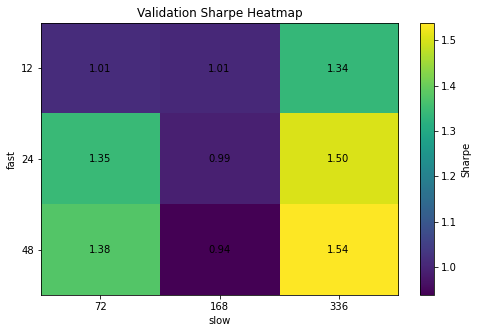

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 7.1 — Sharpe heatmap on VALIDATION
# ============================================

import matplotlib.pyplot as plt

# 1) 把长表变成矩阵
sharpe_matrix = scan_val_df.pivot(index="fast", columns="slow", values="sharpe")

# 2) 画图
plt.figure(figsize=(8, 5))
plt.imshow(sharpe_matrix, aspect="auto")

# 3) 坐标轴
plt.xticks(range(len(sharpe_matrix.columns)), sharpe_matrix.columns)
plt.yticks(range(len(sharpe_matrix.index)), sharpe_matrix.index)

plt.xlabel("slow")
plt.ylabel("fast")
plt.title("Validation Sharpe Heatmap")

# 4) 颜色条
plt.colorbar(label="Sharpe")

# 5) 在格子里写数值
for i in range(sharpe_matrix.shape[0]):
    for j in range(sharpe_matrix.shape[1]):
        value = sharpe_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.show()

In [ ]:
print(val_df.index.min())
print(val_df.index.max())


2023-10-07 01:00:00+00:00
2024-12-18 00:00:00+00:00


这段时期其实是BTC的强势期，线性增长趋势强。

我们从热力图可以看出来slow72，336这两列比较强势，我们在组合多时期信号的时候，是不是可以选择sharpe强的这几段呢？

我们接下来尝试用这个6个时期的参数

在真正实际中，我们要做的事设计稳健信号，而不是找最佳参数

下面代码是筛选掉的参数在训练集跑的结果

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 8 — Filtered multi-horizon ensemble
# ============================================

pairs_filtered = [
    (12,72),(24,72),(48,72),
    (12,336),(24,336),(48,336)
]

data_train = train_df.copy().sort_index()

ret_train = data_train["close"].pct_change()
vol_train = ret_train.ewm(span=24*7, adjust=False).std()

signal_dict = {}

for fast, slow in pairs_filtered:

    ema_fast = data_train["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_train["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1
    signal = trend / vol_train

    signal_norm = signal / signal.rolling(500).std()

    signal_dict[f"{fast}_{slow}"] = signal_norm

signal_df = pd.DataFrame(signal_dict)

combo_signal = signal_df.mean(axis=1)

pos = np.tanh(combo_signal).shift(1).fillna(0)

turnover = pos.diff().abs().fillna(0)
cost = FEE_RATE * turnover

strategy_ret = pos * ret_train - cost

equity = (1 + strategy_ret.fillna(0)).cumprod()

peak = equity.cummax()
drawdown = equity / peak - 1

bt_filtered = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "equity": equity,
    "drawdown": drawdown
})

metrics_filtered = calc_metrics(bt_filtered)

print("=== Filtered Multi-Horizon on TRAIN ===")
print(metrics_filtered)

=== Filtered Multi-Horizon on TRAIN ===
(0.4842276844811938, -0.5179792941513999, 0.5244401217412)


In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 8.1 — Filtered multi-horizon on VALIDATION
# ============================================

pairs_filtered = [
    (12, 72), (24, 72), (48, 72),
    (12, 336), (24, 336), (48, 336)
]

# 1) 当前数据：validation集
data_val = val_df.copy().sort_index()

# 2) 收益率和波动率
ret_val = data_val["close"].pct_change()
vol_val = ret_val.ewm(span=24 * 7, adjust=False).std()

# 3) 构建 filtered signal
signal_dict_val_filtered = {}

for fast, slow in pairs_filtered:
    ema_fast = data_val["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_val["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_val

    # rolling normalization
    signal_norm = signal / signal.rolling(500).std()

    col_name = f"sig_{fast}_{slow}"
    signal_dict_val_filtered[col_name] = signal_norm

# 4) 合成 filtered ensemble signal
signal_df_val_filtered = pd.DataFrame(signal_dict_val_filtered, index=data_val.index)

combo_signal_val_filtered = signal_df_val_filtered.mean(axis=1)

# 5) 仓位映射
pos_val_filtered = np.tanh(combo_signal_val_filtered).shift(1).fillna(0)

# 6) 交易成本
turnover_val_filtered = pos_val_filtered.diff().abs().fillna(0)
cost_val_filtered = FEE_RATE * turnover_val_filtered

# 7) 策略收益
strategy_ret_val_filtered = pos_val_filtered * ret_val - cost_val_filtered

# 8) 资金曲线和回撤
equity_val_filtered = (1 + strategy_ret_val_filtered.fillna(0)).cumprod()
peak_val_filtered = equity_val_filtered.cummax()
drawdown_val_filtered = equity_val_filtered / peak_val_filtered - 1

# 9) 打包结果
bt_val_filtered = pd.DataFrame({
    "strategy_ret": strategy_ret_val_filtered,
    "equity": equity_val_filtered,
    "drawdown": drawdown_val_filtered
}, index=data_val.index)

# 10) 指标
metrics_val_filtered = calc_metrics(bt_val_filtered)

print("=== Filtered Multi-Horizon on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", metrics_val_filtered)

bt_val_filtered.tail()

=== Filtered Multi-Horizon on VALIDATION ===
Sharpe, MaxDD, TotalRet = (0.8798102357132241, -0.2800395946568264, 0.35424370735549804)


,strategy_ret,equity,drawdown
open_time,,,
2024-12-17 20:00:00+00:00,0.002408,1.362315,-0.065735
2024-12-17 21:00:00+00:00,-0.003004,1.358223,-0.068541
2024-12-17 22:00:00+00:00,-0.004118,1.352630,-0.072377
2024-12-17 23:00:00+00:00,0.001521,1.354686,-0.070967
2024-12-18 00:00:00+00:00,-0.000327,1.354244,-0.071270


In [ ]:
print("=== VALIDATION MODEL COMPARISON ===")
print("Single 48/336              :", single_val_metrics)
print("Multi EQ raw               :", combo_val_metrics)
print("Multi EQ normalized        :", metrics_norm_val)
print("Multi filtered normalized  :", metrics_val_filtered)

=== VALIDATION MODEL COMPARISON ===
Single 48/336              : (1.5381557970277204, -0.38193928697480284, 1.1208395160607436)
Multi EQ raw               : (1.0491573042158373, -0.3486533032533258, 0.5811434432668083)
Multi EQ normalized        : (0.8363247728463769, -0.27516592776516546, 0.3291948525559574)
Multi filtered normalized  : (0.8798102357132241, -0.2800395946568264, 0.35424370735549804)


| Model                     | Sharpe   | MaxDD     | Return |
| ------------------------- | -------- | --------- | ------ |
| **Single 48/336**         | **1.54** | -0.38     | 1.12   |
| Multi EQ raw              | 1.05     | -0.35     | 0.58   |
| Multi EQ normalized       | 0.84     | **-0.27** | 0.33   |
| Multi filtered normalized | 0.88     | -0.28     | 0.35   |


在真实研究中我们一般保留三种模型：

1）基线模型baseline  例如这个single-horizon

2）结构模型 structured model 例如这个multi horizon ensemble

3）激进模型 aggressive model 例如这个 raw ensemble 捕捉更高alpha

接下里我们进行 final test，在测试集上对比他们

在test上跑ABC

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 9.1 — Run Model A / B / C on TEST
# ============================================

import numpy as np
import pandas as pd

ANNUAL = 24 * 365
FEE_RATE = 0.0004

# ----------------------------
# 1) 公共指标函数
# ----------------------------
def calc_metrics(bt):
    r = bt["strategy_ret"].dropna()

    sharpe = (r.mean() / r.std()) * np.sqrt(ANNUAL)
    maxdd = bt["drawdown"].min()
    totalret = bt["equity"].iloc[-1] - 1

    return sharpe, maxdd, totalret


# ----------------------------
# 2) Model A: Single Horizon
# ----------------------------
def backtest_single_horizon(df, ema_fast=48, ema_slow=336, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0
    signal = trend / vol

    pos = np.tanh(signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt


# ----------------------------
# 3) Model B: Raw Multi-Horizon Equal Weight
# ----------------------------
def backtest_multi_raw(df, pairs, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    signal_dict = {}

    for fast, slow in pairs:
        ema_fast = data["close"].ewm(span=fast, adjust=False).mean()
        ema_slow = data["close"].ewm(span=slow, adjust=False).mean()

        trend = ema_fast / ema_slow - 1.0
        signal = trend / vol

        signal_dict[f"sig_{fast}_{slow}"] = signal

    signal_df = pd.DataFrame(signal_dict, index=data.index)

    combo_signal = signal_df.mean(axis=1)
    pos = np.tanh(combo_signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt


# ----------------------------
# 4) Model C: Filtered Normalized Multi-Horizon
# ----------------------------
def backtest_multi_filtered_norm(df, pairs_filtered, fee_rate=0.0004, norm_window=500):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    signal_dict = {}

    for fast, slow in pairs_filtered:
        ema_fast = data["close"].ewm(span=fast, adjust=False).mean()
        ema_slow = data["close"].ewm(span=slow, adjust=False).mean()

        trend = ema_fast / ema_slow - 1.0
        signal = trend / vol

        signal_norm = signal / signal.rolling(norm_window).std()

        signal_dict[f"sig_{fast}_{slow}"] = signal_norm

    signal_df = pd.DataFrame(signal_dict, index=data.index)

    combo_signal = signal_df.mean(axis=1)
    pos = np.tanh(combo_signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt


# ----------------------------
# 5) 定义参数组
# ----------------------------
pairs_all = [
    (12, 72), (12, 168), (12, 336),
    (24, 72), (24, 168), (24, 336),
    (48, 72), (48, 168), (48, 336),
]

pairs_filtered = [
    (12, 72), (24, 72), (48, 72),
    (12, 336), (24, 336), (48, 336),
]


# ----------------------------
# 6) 在 TEST 上跑三个模型
# ----------------------------
bt_A_test = backtest_single_horizon(test_df, ema_fast=48, ema_slow=336, fee_rate=FEE_RATE)
bt_B_test = backtest_multi_raw(test_df, pairs=pairs_all, fee_rate=FEE_RATE)
bt_C_test = backtest_multi_filtered_norm(test_df, pairs_filtered=pairs_filtered, fee_rate=FEE_RATE, norm_window=500)

metrics_A_test = calc_metrics(bt_A_test)
metrics_B_test = calc_metrics(bt_B_test)
metrics_C_test = calc_metrics(bt_C_test)

print("=== TEST MODEL COMPARISON ===")
print("Model A | Single 48/336             :", metrics_A_test)
print("Model B | Multi EQ raw             :", metrics_B_test)
print("Model C | Multi filtered normalized:", metrics_C_test)

=== TEST MODEL COMPARISON ===
Model A | Single 48/336             : (0.4702305644101178, -0.3042697861903122, 0.14118511252186883)
Model B | Multi EQ raw             : (-0.2616405524730421, -0.4464763775631261, -0.21704290542667526)
Model C | Multi filtered normalized: (-0.5293399689597382, -0.3635248250772206, -0.23608979025847587)


画三条test资金曲线

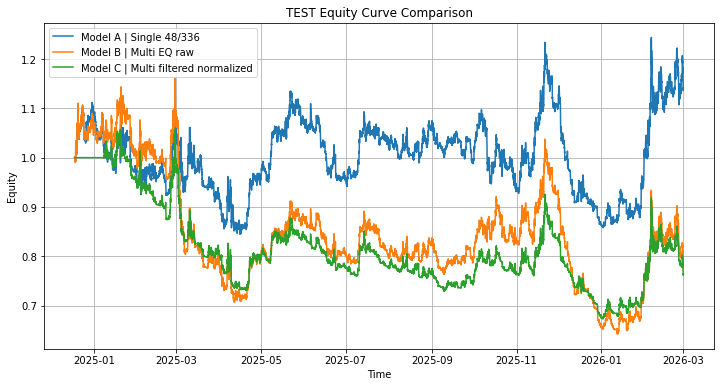

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 9.2 — Plot TEST equity curves
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(bt_A_test.index, bt_A_test["equity"], label="Model A | Single 48/336")
plt.plot(bt_B_test.index, bt_B_test["equity"], label="Model B | Multi EQ raw")
plt.plot(bt_C_test.index, bt_C_test["equity"], label="Model C | Multi filtered normalized")

plt.title("TEST Equity Curve Comparison")
plt.xlabel("Time")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)

plt.show()

test回撤曲线

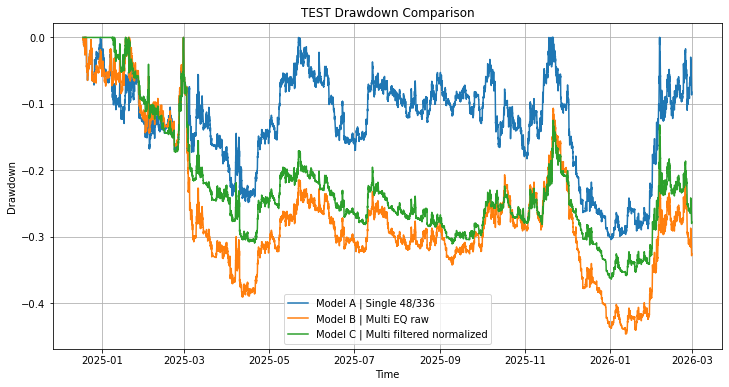

In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 9.3 — Plot TEST drawdown curves
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(bt_A_test.index, bt_A_test["drawdown"], label="Model A | Single 48/336")
plt.plot(bt_B_test.index, bt_B_test["drawdown"], label="Model B | Multi EQ raw")
plt.plot(bt_C_test.index, bt_C_test["drawdown"], label="Model C | Multi filtered normalized")

plt.title("TEST Drawdown Comparison")
plt.xlabel("Time")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.show()

我们这波还没有加入风险控制部分，再一个合成的多期信号，只是对每个时间段信号取了普通平均，我们可以根据sharpe进行加权处理。

然后取看收益曲线，发现其实趋势策略，它仅仅是靠那几段大上升趋势来赚钱的，其他地方是主要是抵抗波动风险，也就是震荡市场被反复止损。因为交易成本+噪音会把资金磨掉。

所以趋势策略优化通常是，减少振荡期的反复交易：

1）波动率过滤

只在 high volatility regime 交易

2）趋势强度过滤 |signal| > threshold

弱信号不交易，减少交易成本

3）volatility targeting
target 20% annual vol  避免仓位过大

接下里对这些模型接入risk控制部分：\
price                           signal

↓

trend signal                    direction = tanh(signal)    

↓           

signal mapping                  size = target_vol / realized_vol

↓

volatility targeting            position = direction × size

↓

position

↓

PnL

# Phase 4 — Risk Model
## Task 4.1 — Volatiolity Targeting
### Step 1 — Build Trend Strategy v2 on Train


带vol targeting 的完整回测函数

杠杆率控制在3倍

In [18]:
# 1) 全数据
df_full = df6y.copy()
df_full = df_full.sort_index()

# 2) 数据长度
n = len(df_full)

# 3) 切分位置
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# 4) 三段数据
train_df = df_full.iloc[:train_end].copy()
val_df   = df_full.iloc[train_end:val_end].copy()
test_df  = df_full.iloc[val_end:].copy()

In [19]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 1 — Single-horizon trend strategy v2
# ============================================

import numpy as np
import pandas as pd

ANNUAL_HOURS = 24 * 365

def backtest_single_horizon_vol_target(
    df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
):
    data = df.copy().sort_index()

    # 1) 市场收益率
    ret = data["close"].pct_change()

    # 2) EMA 趋势信号
    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0

    # 3) 市场波动率（用于 signal 标准化 + 仓位控制）
    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)

    # 4) 风险调整信号
    signal = trend / realized_vol

    # 5) 方向仓位：只决定多空方向和强弱，不决定最终杠杆 direction>0偏多，小于零偏空
    direction = np.tanh(signal).fillna(0)

    # 6) 把年化目标波动率转成小时目标波动率
    target_vol_hourly = target_vol_annual / np.sqrt(ANNUAL_HOURS)

    # 7) vol targeting 仓位大小
    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0)
            #防止目标波动率/当前波动率过大，加一个上线，为三倍仓位
    # 8) 最终目标仓位 = 方向 × 仓位大小
    target_pos = direction * size

    # 9) 避免未来函数：下一根K线才真正持仓
    pos = target_pos.shift(1).fillna(0)

    # 10) 换手与手续费
    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    # 11) 策略收益
    strategy_ret = pos * ret - cost

    # 12) 资金曲线
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    # 13) 回撤
    peak = equity.cummax()
    drawdown = equity / peak - 1

    # 14) 打包结果
    bt = pd.DataFrame({
        "close": data["close"],
        "ret": ret,
        "trend": trend,
        "realized_vol": realized_vol,
        "signal": signal,
        "direction": direction,
        "size": size,
        "target_pos": target_pos,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

In [20]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 2 — Run on TRAIN
# ============================================

#指数函数，在train上和运行

def calc_metrics(bt):
    r = bt["strategy_ret"].dropna()

    sharpe = (r.mean() / r.std()) * np.sqrt(ANNUAL_HOURS)
    maxdd = bt["drawdown"].min()
    totalret = bt["equity"].iloc[-1] - 1

    return sharpe, maxdd, totalret

bt_train_v2 = backtest_single_horizon_vol_target(
    train_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_train_v2 = calc_metrics(bt_train_v2)

print("=== Trend Strategy v2 (Vol Targeting) on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", metrics_train_v2)

bt_train_v2[["direction", "size", "pos", "equity", "drawdown"]].tail()

=== Trend Strategy v2 (Vol Targeting) on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.49953928576353407, -0.23051267226369498, 0.3618674920961755)


,direction,size,pos,equity,drawdown
open_time,,,,,
2023-10-06 20:00:00+00:00,0.999744,0.536089,0.532146,1.363548,-0.093737
2023-10-06 21:00:00+00:00,0.999786,0.535144,0.535952,1.365238,-0.092614
2023-10-06 22:00:00+00:00,0.999807,0.533244,0.535029,1.363385,-0.093846
2023-10-06 23:00:00+00:00,0.999824,0.532626,0.533141,1.362340,-0.094540
2023-10-07 00:00:00+00:00,0.999851,0.537235,0.532533,1.361867,-0.094854


In [21]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 3 — Compare old vs new on TRAIN
# ============================================
#和不加波动率控制的比较
def backtest_single_horizon_basic(df, ema_fast=48, ema_slow=336, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0
    signal = trend / vol

    pos = np.tanh(signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

bt_train_v1 = backtest_single_horizon_basic(train_df, ema_fast=48, ema_slow=336)
metrics_train_v1 = calc_metrics(bt_train_v1)

print("=== TRAIN COMPARISON ===")
print("v1 | Single Horizon Basic       :", metrics_train_v1)
print("v2 | Single Horizon Vol Target  :", metrics_train_v2)

=== TRAIN COMPARISON ===
v1 | Single Horizon Basic       : (0.390308610887072, -0.6113292627796767, 0.12881223007974496)
v2 | Single Horizon Vol Target  : (0.49953928576353407, -0.23051267226369498, 0.3618674920961755)


这一结果显示vol targeting部分非常有效果，在CTA策略中，主要是小时间的大趋势赚钱，其他大部分时间都是在市场的震荡中，加入这一部分可以让回撤被压制，风险可控

下一步去验证风险模型在validation集是否稳健

In [22]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 4 — Run on VALIDATION
# ============================================
#v2在validation 运行

bt_val_v2 = backtest_single_horizon_vol_target(
    val_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_val_v2 = calc_metrics(bt_val_v2)

print("=== Trend Strategy v2 (Vol Targeting) on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", metrics_val_v2)

=== Trend Strategy v2 (Vol Targeting) on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.5636577421963875, -0.17667301139416147, 0.4521754203199526)


In [23]:
bt_val_v1 = backtest_single_horizon_basic(val_df, ema_fast=48, ema_slow=336)

metrics_val_v1 = calc_metrics(bt_val_v1)

print("=== VALIDATION COMPARISON ===")
print("v1 | Basic       :", metrics_val_v1)
print("v2 | Vol Target  :", metrics_val_v2)

=== VALIDATION COMPARISON ===
v1 | Basic       : (1.5381557970277204, -0.38193928697480284, 1.1208395160607436)
v2 | Vol Target  : (1.5636577421963875, -0.17667301139416147, 0.4521754203199526)


sharpe没变，但是风险减半，这是vol的典型效果，风险稳定化。

为什么return下降?

因为basic的模型，其实没控制杠杆，v2模型leverage变低，原始策略有时候仓位会很大，这当然也会导致drawdown也很大

接下里，让模型在test上运行。

In [24]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 5 — Run on TEST
# ============================================

bt_test_v2 = backtest_single_horizon_vol_target(
    test_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_test_v2 = calc_metrics(bt_test_v2)

print("=== Trend Strategy v2 (Vol Targeting) on TEST ===")
print("Sharpe, MaxDD, TotalRet =", metrics_test_v2)

=== Trend Strategy v2 (Vol Targeting) on TEST ===
Sharpe, MaxDD, TotalRet = (0.6059433388213068, -0.14342195638680777, 0.13336293701986324)


In [25]:
bt_test_v1 = backtest_single_horizon_basic(test_df, ema_fast=48, ema_slow=336)

metrics_test_v1 = calc_metrics(bt_test_v1)

print("=== TEST COMPARISON ===")
print("v1 | Basic       :", metrics_test_v1)
print("v2 | Vol Target  :", metrics_test_v2)

=== TEST COMPARISON ===
v1 | Basic       : (0.4702305644101178, -0.3042697861903122, 0.14118511252186883)
v2 | Vol Target  : (0.6059433388213068, -0.14342195638680777, 0.13336293701986324)


这一结果不错，在使用vol组件之后明显发现最大回撤显著降低。

但是我们还缺一个关键组件，我们之前观察到，trend strategy大部分时间是在震荡的，所以问题是 Whipsaw，信号的反复会导致**反复交易**升高成本

解决这个问题的经典方法是**signal threshold** 信号阈值

在信号很小的时候|signal|很小，这时候去交易，其实信号是个噪声，

所以在CTA系统加入，|signal|> threshold  可以控制弱信号不交易，减少振荡周期交易

大部分ema_fast/eam_slow-1是负数，正负决定方向，大小决定强度。所以绝对值更重要。

通常signal threshold一般在0.2-1之间，所以我们一般不会固定选一个值，而是做\
threshold scan

## Task4.2 Signal Threshold
### Step2 Threshold Scan on Train

In [26]:
# ============================================
# Phase 4 — Risk Model
# Task 4.2 — Signal Threshold
# Step 2 — Threshold scan on TRAIN
# ============================================

def backtest_single_horizon_threshold(
    df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold=0.0,
    fee_rate=0.0004,
    max_leverage=3.0
):

    data = df.copy().sort_index()

    ret = data["close"].pct_change()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1

    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)

    signal = trend / realized_vol

    # -------- threshold filter --------
    filtered_signal = signal.copy()
    filtered_signal[abs(filtered_signal) < threshold] = 0

    direction = np.tanh(filtered_signal).fillna(0)

    target_vol_hourly = 0.20 / np.sqrt(24 * 365)

    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0)

    target_pos = direction * size

    pos = target_pos.shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)

    cost = fee_rate * turnover

    strat_ret = pos * ret - cost

    equity = (1 + strat_ret).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "pos": pos,
        "turnover": turnover,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown
    })

    return bt

In [27]:
threshold_list = [0, 0.2, 0.3, 0.5, 1]

results = []

for th in threshold_list:

    bt = backtest_single_horizon_threshold(
        train_df,
        threshold=th
    )

    sharpe, maxdd, ret = calc_metrics(bt)

    turnover = bt["turnover"].sum()

    results.append({
        "threshold": th,
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret,
        "turnover": turnover
    })

scan_df = pd.DataFrame(results)

scan_df

,threshold,sharpe,maxdd,ret,turnover
0,0.0,0.499539,-0.230513,0.361867,293.820805
1,0.2,0.504759,-0.229490,0.367488,292.681620
2,0.3,0.509711,-0.228565,0.372817,292.734285
3,0.5,0.542911,-0.232782,0.409031,292.025075
4,1.0,0.550380,-0.212370,0.414073,284.231533


turnover是交易强度，turnover是绝对值变化 比如0.2变为-0.3，turnover就是0.5

### Step3 Threshold Scan on Validation

In [28]:
# ============================================
# Phase 4 — Risk Model
# Task 4.2 — Signal Threshold
# Step 3 — Threshold scan on VALIDATION
# ============================================

threshold_list = [0, 0.2, 0.3, 0.5, 1]

results_val = []

for th in threshold_list:

    bt_val_th = backtest_single_horizon_threshold(
        val_df,
        ema_fast=48,
        ema_slow=336,
        vol_lookback=72,
        target_vol_annual=0.20,
        threshold=th,
        fee_rate=0.0004,
        max_leverage=3.0
    )

    sharpe, maxdd, ret = calc_metrics(bt_val_th)
    turnover = bt_val_th["turnover"].sum()

    results_val.append({
        "threshold": th,
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret,
        "turnover": turnover
    })

scan_val_threshold_df = pd.DataFrame(results_val)

print("=== VALIDATION THRESHOLD SCAN ===")
print(scan_val_threshold_df)

=== VALIDATION THRESHOLD SCAN ===
   threshold    sharpe     maxdd       ret   turnover
0        0.0  1.563658 -0.176673  0.452175  93.453330
1        0.2  1.586872 -0.176400  0.460777  93.292327
2        0.3  1.592764 -0.177425  0.462851  93.618813
3        0.5  1.481021 -0.182237  0.420976  94.993090
4        1.0  1.467508 -0.183639  0.412883  93.592238


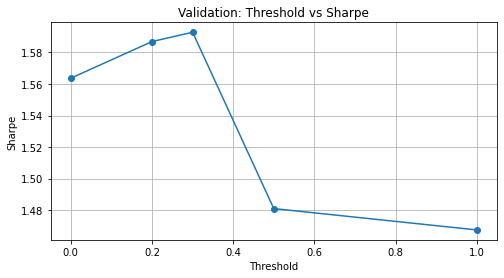

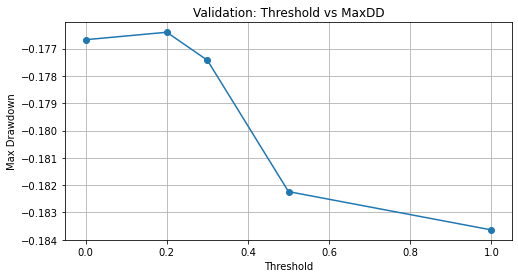

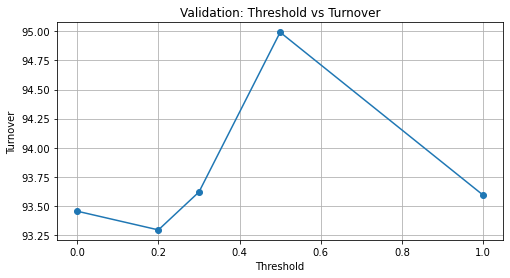

In [29]:
# ============================================
# Phase 4 — Risk Model
# Task 4.2 — Signal Threshold
# Step 4 — Plot validation threshold curves
# ============================================

import matplotlib.pyplot as plt

# 1) Sharpe
plt.figure(figsize=(8, 4))
plt.plot(scan_val_threshold_df["threshold"], scan_val_threshold_df["sharpe"], marker="o")
plt.title("Validation: Threshold vs Sharpe")
plt.xlabel("Threshold")
plt.ylabel("Sharpe")
plt.grid(True)
plt.show()

# 2) Max Drawdown
plt.figure(figsize=(8, 4))
plt.plot(scan_val_threshold_df["threshold"], scan_val_threshold_df["maxdd"], marker="o")
plt.title("Validation: Threshold vs MaxDD")
plt.xlabel("Threshold")
plt.ylabel("Max Drawdown")
plt.grid(True)
plt.show()

# 3) Turnover
plt.figure(figsize=(8, 4))
plt.plot(scan_val_threshold_df["threshold"], scan_val_threshold_df["turnover"], marker="o")
plt.title("Validation: Threshold vs Turnover")
plt.xlabel("Threshold")
plt.ylabel("Turnover")
plt.grid(True)
plt.show()

TRAIN
| threshold | Sharpe |
| --------- | ------ |
| 0         | 0.50   |
| 0.3       | 0.51   |
| 0.5       | 0.54   |
| 1         | 0.55   |


VALIDATION
| threshold | Sharpe |
| --------- | ------ |
| 0         | 1.56   |
| 0.2       | 1.59   |
| 0.3       | 1.59   |
| 0.5       | 1.48   |
| 1         | 1.47   |

threshold 在0.2-0.3区域内是比较稳定的

下一步我们把threshold=0.3放在test集去看

In [32]:
bt_test_v3 = backtest_single_horizon_threshold(
    test_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold=0.3,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_test_v3 = calc_metrics(bt_test_v3)


print("===  COMPARISON on Test ===")
print("v1 | Basic       :", metrics_test_v1)
print("v2 | Vol Target  :", metrics_test_v2)
print("v3 | vol Target+Threshold(0.3)  :", metrics_test_v3)

===  COMPARISON on Test ===
v1 | Basic       : (0.4702305644101178, -0.3042697861903122, 0.14118511252186883)
v2 | Vol Target  : (0.6059433388213068, -0.14342195638680777, 0.13336293701986324)
v3 | vol Target+Threshold(0.3)  : (0.6361112165450922, -0.14389053021431097, 0.14186995729467977)


对于threshold，因为signal的分布会随着市场的regime改变，所以很多CTA都会用：\
Dynamic threshold 也就是动态阈值

动态阈值怎么选，一般用 signal percentile 信号百分位数比较合理：

abs(signal) > rolling_percentile(abs(signal), q)

这个rolling_percentil的窗口，本质上实在控制threshold学习市场状态的速度。对于1小时数据，窗口太短threshold容易变化太快，容易被短期噪音带着跑，过滤器本身不稳定，太长太迟钝。中等窗口比较合适。


## Task4.3 Dynamic Threshold
### Step1 Rolling percentil threshold

1）threshold类型 我们就用abs（signal）

2）percentile值，我们先扫q_list=[0.6,0.7,0.8]\
    即交易最近窗口里强度排名前40%，30%，20%

3）rolling window  window_list = [七天, 14天, 24天]

这里这个dynamic threshold逻辑：

首先，先取绝对值 让strength= abs（signal），这里threshold只反应强弱

其次，对过去一段时间做rolling percentile，这个值也是绝对值非负的，然后对它取分位数。

然后，使用当前时间点的signal 绝对值跟这个比较，如果小于threshold就直接赋值为0，不做多不做空。代入运算direction的时候还是用带正负的signal


#### Step 3 — Rolling Percentile Threshold Backtest

动态阈值版本完整回测函数（未扫描）

In [33]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 3 — Rolling Percentile Threshold Backtest
# ============================================

def backtest_single_horizon_dynamic_threshold(
    df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    fee_rate=0.0004,
    max_leverage=3.0
):
    data = df.copy().sort_index()

    # 1) 收益率
    ret = data["close"].pct_change()

    # 2) EMA trend
    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0

    # 3) 市场波动率
    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)

    # 4) 原始 signal
    signal = trend / realized_vol

    # 5) signal strength（只看强度，不看方向）
    signal_strength = signal.abs()

    # 6) rolling dynamic threshold
    dynamic_threshold = signal_strength.rolling(threshold_window).quantile(threshold_quantile)

    # 7) 硬过滤：弱信号直接归零，强信号保留原始正负号
    filtered_signal = signal.copy()
    filtered_signal[signal_strength < dynamic_threshold] = 0

    # 8) 方向映射
    direction = np.tanh(filtered_signal).fillna(0)

    # 9) 年化目标波动率 → 小时目标波动率
    target_vol_hourly = target_vol_annual / np.sqrt(24 * 365)

    # 10) vol targeting 仓位大小
    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0)

    # 11) 最终目标仓位
    target_pos = direction * size

    # 12) 避免未来函数
    pos = target_pos.shift(1).fillna(0)

    # 13) 换手与手续费
    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    # 14) 策略收益
    strategy_ret = pos * ret - cost

    # 15) 资金曲线
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    # 16) 回撤
    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "close": data["close"],
        "ret": ret,
        "trend": trend,
        "realized_vol": realized_vol,
        "signal": signal,
        "signal_strength": signal_strength,
        "dynamic_threshold": dynamic_threshold,
        "filtered_signal": filtered_signal,
        "direction": direction,
        "size": size,
        "target_pos": target_pos,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

在TRAIN上扫描quantile和window

In [34]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 4 — Train Grid Scan
# ============================================

quantile_list = [0.6, 0.7, 0.8]
window_list = [24 * 7, 24 * 14, 24 * 30]

results_dynamic_train = []

for q in quantile_list:
    for w in window_list:

        bt_dyn_train = backtest_single_horizon_dynamic_threshold(
            train_df,
            ema_fast=48,
            ema_slow=336,
            vol_lookback=72,
            target_vol_annual=0.20,
            threshold_window=w,
            threshold_quantile=q,
            fee_rate=0.0004,
            max_leverage=3.0
        )

        sharpe, maxdd, ret = calc_metrics(bt_dyn_train)
        turnover = bt_dyn_train["turnover"].sum()

        results_dynamic_train.append({
            "quantile": q,
            "window_hours": w,
            "window_days": w / 24,
            "sharpe": sharpe,
            "maxdd": maxdd,
            "ret": ret,
            "turnover": turnover
        })

scan_dynamic_train_df = pd.DataFrame(results_dynamic_train)

print("=== TRAIN DYNAMIC THRESHOLD SCAN ===")
print(scan_dynamic_train_df.sort_values("sharpe", ascending=False))

=== TRAIN DYNAMIC THRESHOLD SCAN ===
   quantile  window_hours  window_days    sharpe     maxdd       ret  \
7       0.8           336         14.0  0.998555 -0.171733  0.537609   
5       0.7           720         30.0  0.845147 -0.176045  0.500787   
2       0.6           720         30.0  0.745261 -0.203265  0.459717   
4       0.7           336         14.0  0.684736 -0.228205  0.374273   
8       0.8           720         30.0  0.531012 -0.164406  0.243365   
0       0.6           168          7.0  0.325718 -0.207616  0.155578   
3       0.7           168          7.0  0.301169 -0.247727  0.129376   
1       0.6           336         14.0  0.174954 -0.291924  0.056205   
6       0.8           168          7.0  0.099358 -0.230741  0.016043   

     turnover  
7  250.226167  
5  250.618754  
2  259.305071  
4  266.181585  
8  204.211323  
0  375.175528  
3  380.011606  
1  312.611675  
6  359.586224  


这个动态的阈值比固定阈值的sharpe要好很多，尤其是接近1，但是注意一点，到底是不是过拟合，所以我们要注意在validation上面的表现！

画train热力图（sharpe）

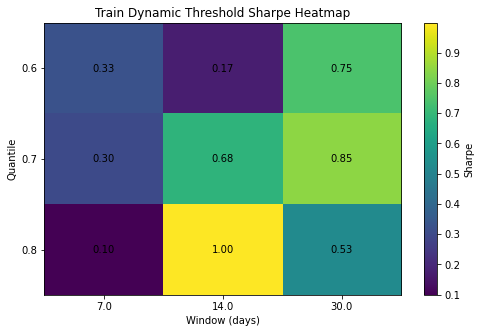

In [35]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 5 — Train Sharpe Heatmap
# ============================================

import matplotlib.pyplot as plt

train_dyn_matrix = scan_dynamic_train_df.pivot(
    index="quantile",
    columns="window_days",
    values="sharpe"
)

plt.figure(figsize=(8, 5))
plt.imshow(train_dyn_matrix, aspect="auto")

plt.xticks(range(len(train_dyn_matrix.columns)), train_dyn_matrix.columns)
plt.yticks(range(len(train_dyn_matrix.index)), train_dyn_matrix.index)

plt.xlabel("Window (days)")
plt.ylabel("Quantile")
plt.title("Train Dynamic Threshold Sharpe Heatmap")

plt.colorbar(label="Sharpe")

for i in range(train_dyn_matrix.shape[0]):
    for j in range(train_dyn_matrix.shape[1]):
        value = train_dyn_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.show()

我们选出来一些candidate 参数：

Condidate A：

quantile = 0.8\
window = 14d\
Sharpe = 1.00

Condidate B:

quantile = 0.8\
window = 14d\
Sharpe = 1.00

Condidate C:

quantile = 0.7\
window = 30d\
Sharpe = 0.85

接下来在validation上面去看这三组参数，虽然validation全扫描也可以，但是这样更常见，去看这组参数到底是不是过拟合，能不能用